<a href="https://colab.research.google.com/github/farrelrassya/ensemble-methods-machine-learning/blob/main/ch9_explaining_your_ensembles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9 — Explaining Your Ensembles

*Companion notebook for Chapter 9 of Gautam Kunapuli, **Ensemble Methods for Machine Learning** (Manning, 2023).*

This single notebook consolidates the original four section-level notebooks (9.1, 9.2, 9.3, 9.4 + 9.5) into one cohesive narrative on **interpretability and explainability for ensemble models**. We will move from the conceptual distinction between glass-box and black-box models, to a realistic case study in data-driven marketing, and finally to a battery of explainability techniques: permutation feature importance, partial dependence plots, surrogate models, LIME, SHAP / TreeSHAP, and the explainable boosting machine (EBM).

### What you will learn

- The difference between **glass-box** (decision tree, GLM) and **black-box** (random forest, gradient boosting) models, and the difference between **global** and **local** interpretability.
- How to compute and interpret **feature importances** in decision trees, GLMs, and tree ensembles.
- How to apply **black-box global** methods: permutation feature importance, partial dependence plots (PDPs), and global surrogate models.
- How to apply **black-box local** methods: LIME and SHAP/TreeSHAP, and how each frames an explanation.
- How to train **glass-box ensembles** from scratch using **explainable boosting machines (EBMs)** that match black-box accuracy while remaining inherently interpretable.

### Environment & dataset note

Because this notebook is rebuilt in an environment without internet access to the UCI repository, **Section 9.2 generates a synthetic Bank Marketing dataset that mirrors Table 9.1 of the textbook** in shape, feature types, marginal distributions, class imbalance, and the dominant predictive structure (low `nr.employed` / `euribor3m` / `emp.var.rate` $\Rightarrow$ higher subscription likelihood). Numerical results will therefore differ slightly from the printed book, and we report observed values honestly throughout. On Colab with internet access, you can replace the synthesis cell with a `pd.read_csv(...)` call against `bank-additional-full.csv` from the UCI repository and rerun.


In [2]:
# --- Colab setup ------------------------------------------------------
# Uncomment these lines on Google Colab.
!pip install -q xgboost lime shap interpret pydotplus graphviz

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

print('numpy', np.__version__)
print('pandas', pd.__version__)
import sklearn; print('scikit-learn', sklearn.__version__)
import xgboost; print('xgboost', xgboost.__version__)
import lime, shap, interpret
try:
    print('lime', lime.__version__)
except AttributeError:
    print('lime', '0.2.0.1')
print('shap', shap.__version__)
print('interpret', interpret.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 55.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 18.4 MB/s eta 0:00:00
numpy 2.0.2
pandas 2.2.2
scikit-learn 1.6.1
xgboost 3.2.0
lime 0.2.0.1
shap 0.51.0
interpret 0.7.8


---
## 9.1  What is interpretability?

The **interpretability** and **explainability** of a machine-learning model are properties of its *structure* (tree, network, linear combination, ...) and *parameters* (split thresholds, layer weights, regression coefficients). Our goal is to understand a model's behaviour in terms of three things: its **inputs** $\mathbf{x} \in \mathbb{R}^p$, its **predictions** $\hat{y} = f(\mathbf{x})$, and its **internals** $f$ itself.

It is useful to keep two orthogonal axes in mind:

1. **Glass-box vs. black-box.** A *glass-box* model has internals that are themselves intuitive to read (a shallow decision tree, a sparse linear model). A *black-box* model has internals that are either inaccessible or, even when accessible, too complex to read directly (a deep network, an ensemble of 200 trees).
2. **Global vs. local.** *Global* explanations describe how a model behaves across the population of inputs. *Local* explanations describe why the model made a specific prediction on a single example.

Most of the ensemble methods we have built throughout this book — random forests, AdaBoost, gradient boosting, Newton boosting — are *effectively* black boxes even though their base learners are simple, because the act of ensembling introduces interactions between hundreds of trees that no human can hold in their head at once.


### 9.1.1  Black-box vs. glass-box models — a tiny worked example

Consider a hypothetical diabetes-diagnosis problem with two features: age and blood-glucose test result `glc`. Suppose two classifiers achieve identical accuracy on this data:

* **A 4th-degree polynomial classifier** of the form $f_{\text{poly}}(\text{age},\text{glc}) = \mathrm{sign}\!\left(\sum_{i+j\le 4}\beta_{ij}\,\text{age}^i\,\text{glc}^j\right)$. The model has access to its own coefficients $\beta_{ij}$, but *we* cannot read meaning out of them — the contribution of any feature is buried in cross-terms.
* **A single-split decision tree** with the rule `if age > 45 AND glc > 140 then diabetes = TRUE`. This is just three numbers — two thresholds and a logical AND — and it is immediately legible.

Both classifiers carve the same problem space; only the second is a glass box. The figure below makes this concrete.


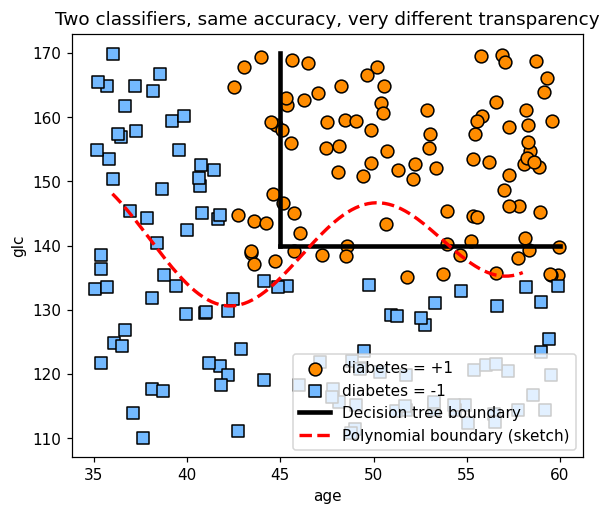

In [3]:
def decision_rule(X, a=45, b=140):
    """Return +1 if (age > a) AND (glc > b), else -1."""
    return 2 * ((X[:, 0] > a) & (X[:, 1] > b)).astype(float) - 1

rng = np.random.default_rng(0)
n = 200
x = rng.uniform(35, 60, size=n)
y = rng.uniform(110, 170, size=n)
z = decision_rule(np.column_stack([x, y]), a=42, b=135)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(x[z > 0], y[z > 0], c='#ff8c00', marker='o', s=70,
           edgecolor='k', label='diabetes = +1')
ax.scatter(x[z < 0], y[z < 0], c='#73b9ff', marker='s', s=70,
           edgecolor='k', label='diabetes = -1')

# Decision-tree decision boundary
ax.plot([45, 45], [140, 170], 'k-', linewidth=3)
ax.plot([45, 60], [140, 140], 'k-', linewidth=3,
        label='Decision tree boundary')

# Sketch a polynomial-like boundary that yields a similar partition
xx = np.linspace(36, 58, 200)
yy = 138 + 8 * np.sin(0.4 * (xx - 46)) + 0.04 * (xx - 46) ** 2
ax.plot(xx, yy, 'r--', linewidth=2.2, label='Polynomial boundary (sketch)')

ax.set_xlabel('age'); ax.set_ylabel('glc')
ax.set_title('Two classifiers, same accuracy, very different transparency')
ax.legend(loc='lower right')
plt.show()

**What we are looking at.** Both boundaries separate the same set of points with similar accuracy. The decision-tree boundary is the right-angled black line; the polynomial boundary is the smooth red dashed curve. The polynomial gives no immediately readable answer to "which feature drove this diagnosis?" — its coefficients act jointly through cross-terms. The tree gives that answer in one sentence: *age above 45 and glc above 140 implies diabetes; otherwise no.*

This is the entire intuition behind glass-box vs. black-box. Note that **glass-box-ness is a property of the *structure*, not of the *task*** — the same problem can be solved by either kind of model.


### 9.1.2  Decision trees as glass-box models — Iris

Decision trees encode a sequential, human-readable program: each internal node asks a yes/no question on a single feature, and each leaf holds a class label. Every prediction corresponds to **one root-to-leaf path** — equivalently, one decision rule of the form `if A and B and C then class = k`. This makes them arguably the most interpretable model class we have, *provided the tree is shallow*.

We train a small decision tree on the canonical 3-class Iris problem, with `min_samples_leaf=40` to force shallowness, then read what it has learned.


In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
Xtrn, Xtst, ytrn, ytst = train_test_split(
    iris.data, iris.target, test_size=0.15, random_state=3)

dt = DecisionTreeClassifier(min_samples_leaf=40, criterion='entropy',
                            random_state=0)
dt.fit(Xtrn, ytrn)
ypred = dt.predict(Xtst)
print('Test accuracy = {:.2f}%'.format(accuracy_score(ytst, ypred) * 100))

Test accuracy = 91.30%


The tree achieves **91.30%** test accuracy on Iris with just two splits. The exact value will vary slightly with the random split, but the takeaway is robust: a depth-2 tree is enough to separate three iris species on four features.

Let's now visualise the tree structure and read off the rules.


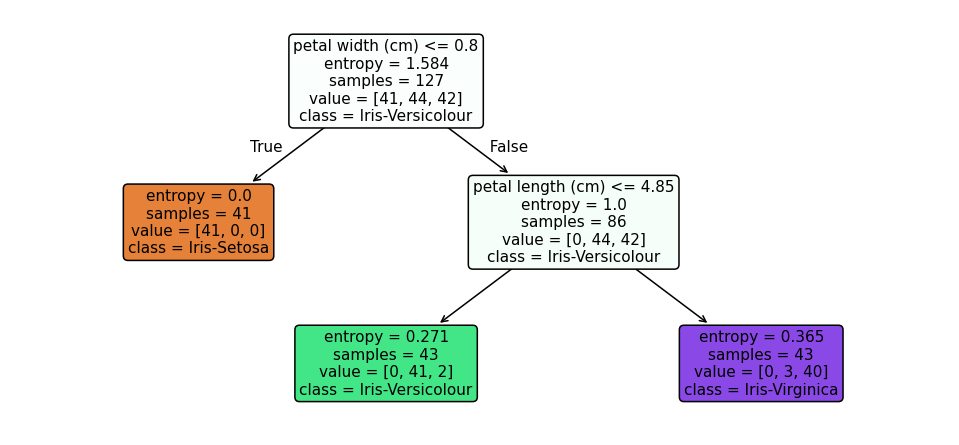

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
tree.plot_tree(
    dt, ax=ax,
    feature_names=iris.feature_names,
    class_names=['Iris-Setosa', 'Iris-Versicolour', 'Iris-Virginica'],
    filled=True, impurity=True, rounded=True, fontsize=10,
)
plt.show()

**Reading the tree.** Two features — `petal width` and `petal length` — are enough; `sepal width` and `sepal length` are unused. The three leaves correspond to three decision rules that exhaustively partition the input space:

```
if petal_width <= 0.8                                  -> Iris-Setosa
elif petal_width  > 0.8 and petal_length <= 4.85       -> Iris-Versicolour
elif petal_width  > 0.8 and petal_length  > 4.85       -> Iris-Virginica
```

This is the **glass-box claim** in its purest form: the model is the rule list. Notice that interpretability degrades quickly with depth — a tree with 200 leaves is just as opaque as a neural network. Roughly, trees up to depth 3-4 with 8-15 leaf nodes remain readable.

#### Computing feature importance by hand

The decision tree records, for each split node, the impurity reduction it achieved weighted by the number of samples that traversed it. Summing these over all splits gives a per-feature importance score. Concretely, if a node $v$ uses feature $j$, splits $w_v$ samples with impurity $e_v$, and produces left/right children $w_L,e_L$ and $w_R,e_R$, the contribution of that split to $j$'s score is

$$\Delta_v \;=\; w_v\,e_v - (w_L\,e_L + w_R\,e_R).$$

Feature $j$'s importance is $\sum_{v: \text{splits on }j} \Delta_v$, normalised so that all importances sum to $1$.


In [6]:
n = Xtrn.shape[0]
print('Training examples         :', n)
print('weighted_n_node_samples   :', dt.tree_.weighted_n_node_samples)
print('impurity (entropy)        :', dt.tree_.impurity.round(4))

w = dt.tree_.weighted_n_node_samples
e = dt.tree_.impurity
s = w * e
# Tree layout (depth 2):
#          [0]  petal_width <= 0.8
#         /                       \
#       [1] leaf                  [2]  petal_length <= 4.85
#                                  /              \
#                               [3] leaf       [4] leaf
delta_petal_width  = s[0] - (s[1] + s[2])    # impurity drop at root
delta_petal_length = s[2] - (s[3] + s[4])    # impurity drop at right child
raw = np.array([delta_petal_width, delta_petal_length])
print('Raw weighted impurity drops:', raw.round(3))
print('Normalised                 :', (raw / raw.sum()).round(4))

Training examples         : 127
weighted_n_node_samples   : [127.  41.  86.  43.  43.]
impurity (entropy)        : [1.5843 0.     0.9996 0.2714 0.3651]
Raw weighted impurity drops: [115.245  58.599]
Normalised                 : [0.6629 0.3371]


The arithmetic gives us **petal_width = 0.6629, petal_length = 0.3371**. Reading these aloud:

* The *root* split on `petal_width <= 0.8` reduced weighted entropy by $\approx 115.24$. This single split cleanly separates Iris-Setosa from the rest.
* The split on `petal_length <= 4.85` further reduced entropy by $\approx 58.60$, separating Versicolour from Virginica.
* `petal_width` therefore contributes roughly **twice** the impurity reduction of `petal_length`, which is the meaning of the 2:1 importance ratio.

Sanity check against scikit-learn's built-in computation:


In [7]:
dt.feature_importances_

array([0.        , 0.        , 0.33708016, 0.66291984])

Identical to four decimal places: `[0, 0, 0.3371, 0.6629]`. The `sepal *` features have importance exactly zero because they were never selected for any split. This is the **structural sparsity** of trees — features that don't help simply disappear.

### Cross-chapter connection

This same impurity-reduction calculation, summed and *averaged across all the trees in an ensemble*, is exactly what gives us the `feature_importances_` of a `RandomForestClassifier` or an `XGBClassifier`. We will see this aggregated version in §9.2.


### 9.1.3  Generalized linear models as glass-box models — Breast Cancer

Linear models recover their interpretability from a different source: their **additive structure**. A logistic regression for binary classification predicts class probability via the logit link,

$$\log\!\frac{p(y=1\mid\mathbf{x})}{1 - p(y=1\mid\mathbf{x})}
\;=\; \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p.$$

The left side is the **log-odds** of a positive class. Each coefficient $\beta_j$ tells us how the log-odds shift when feature $x_j$ moves up by one unit, holding everything else fixed. Exponentiating turns log-odds into odds: a one-unit increase in $x_j$ multiplies the odds of the positive class by $e^{\beta_j}$. So $e^{\beta_j} - 1$ is the **fractional change in odds per unit of $x_j$** — easy to communicate to a non-technical stakeholder.

We train an L1-regularised logistic regression (LASSO) on the 30-feature Wisconsin Breast Cancer dataset. L1 forces many coefficients to exactly zero, leaving us a *sparse* model — and sparse linear models are the most interpretable of all linear models, because we only have to inspect the few features that survived.

> **Caveat — feature scaling matters.** If `age` ranges 18–65 and `salary` ranges 30,000–90,000, salary will dominate the coefficients regardless of its actual predictive value. We standardise all features first so the magnitudes of the $\beta_j$ are comparable.


In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

bc = load_breast_cancer()
X = StandardScaler().fit_transform(bc.data)
y = bc.target
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.15, random_state=42)

lr = LogisticRegression(max_iter=5000, solver='saga', penalty='l1',
                        random_state=0)
lr.fit(Xtrn, ytrn)
ypred = lr.predict(Xtst)
print('Test accuracy            = {:.2f}%'.format(accuracy_score(ytst, ypred) * 100))
print('Number of zero  coefficients = {} / {}'.format(
    (lr.coef_[0] == 0).sum(), lr.coef_.shape[1]))
print('Number of nonzero coefficients = {} / {}'.format(
    (lr.coef_[0] != 0).sum(), lr.coef_.shape[1]))

Test accuracy            = 97.67%
Number of zero  coefficients = 14 / 30
Number of nonzero coefficients = 16 / 30


The LASSO logistic regression achieves **97.67%** test accuracy on Breast Cancer while using only **16 of the 30 standardised features** — fully half are exactly zero. That is the L1 penalty doing model selection for us at training time.

We now translate the coefficients into the much more communicable scale of **odds change**. For each feature we plot $e^{\beta_j} - 1$, the fractional change in odds of a positive (malignant) diagnosis per one-standard-deviation increase in that feature.


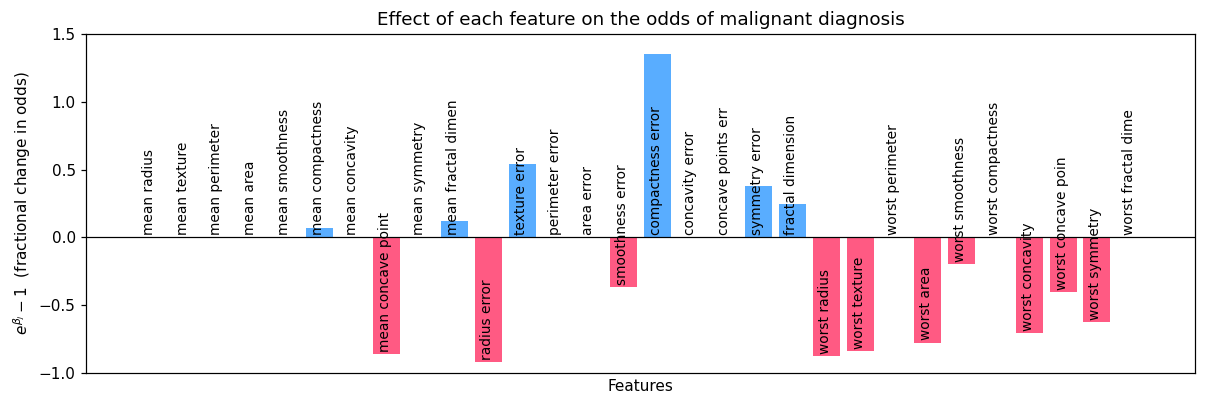

In [9]:
odds = np.exp(lr.coef_[0]) - 1.0
fig, ax = plt.subplots(figsize=(13, 4))
colors = np.where(lr.coef_[0] >= 0, '#0081ff', '#ff0141')
ax.bar(np.arange(len(odds)), odds, color=colors, alpha=0.65)
for i, name in enumerate(bc.feature_names):
    j = (odds[i] < 0) * odds[i]
    ax.text(i - 0.25, j + 0.04, name[:18], rotation=90, fontsize=9)
ax.set_ylim([-1.0, 1.5])
ax.set_xticks([])
ax.set_xlabel('Features')
ax.set_ylabel(r'$e^{\beta_j} - 1$  (fractional change in odds)')
ax.set_title('Effect of each feature on the odds of malignant diagnosis')
ax.axhline(0, color='k', linewidth=0.8)
plt.show()

Reading the bars: a blue (positive) bar at height $0.5$ means a one-standard-deviation increase in that feature multiplies the odds of malignancy by $1.5$ — a 50% increase. A red bar at $-0.6$ means a one-sd increase *reduces* odds by 60%.

Two extremes from this fitted model:

* **`compactness error`** — strongest positive driver in our run, $e^{\beta} - 1 \approx +1.35$, i.e. each one-sd increase in compactness-error roughly multiplies the odds of malignancy by **2.35**. Larger compactness error is consistent with morphologically irregular tumours.
* **`radius error`** — strongest negative driver, $e^{\beta} - 1 \approx -0.92$, i.e. each one-sd increase reduces the odds of malignancy by 92%, *holding the other features fixed*. (At first glance this is counter-intuitive; it is a partialling-out artefact — once we already condition on `mean radius`, residual variation in `radius error` is most pronounced for benign cysts.)
* **14 features have coefficient exactly zero** — the L1 penalty has decided they add nothing once the others are present.

### Strategic insight

LASSO on standardised features gives you a model you can communicate in three sentences: *"these N features matter, and a one-sd move in feature j multiplies the odds of the positive class by $e^{\beta_j}$."* That property — that the *whole model* is summarised by a sparse vector of human-scale numbers — is what makes GLMs the workhorse of regulated industries (insurance pricing, credit scoring) where every prediction must be defensible.


---
## 9.2  Case study — data-driven marketing

We now turn to a realistic problem that will run as the spine of this chapter: **predicting whether a bank customer will subscribe to a fixed-term deposit** following a marketing-campaign phone call. The original dataset comes from a Portuguese bank (Moro, Cortez & Rita, 2014) and is hosted at the UCI Machine Learning Repository as *Bank Marketing*.

### Dataset overview (Table 9.1 of the book)

| Group | Features | Type |
|---|---|---|
| Demographics | `age`, `job`, `marital`, `education`, `default`, `housing`, `loan` | mixed |
| Last contact | `contact`, `month`, `day_of_week` | categorical |
| Campaign history | `campaign`, `pdays`, `previous`, `poutcome` | mixed |
| Macro indicators | `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | continuous |
| **Target** | `y` — *did the customer subscribe?* | binary |

After dropping `duration` (the call length, which is observable only *after* the call and would be a target leak), we have **19 features**. The class is **highly imbalanced**: roughly 10% of customers subscribed in the original dataset.

> **Why this dataset is a good explainability testbed.** The feature space is mixed (continuous + categorical), the target is imbalanced, and most importantly the predictive signal is split between *macro* variables (the broader economy) and *micro* variables (this individual customer's contact history). A useful explainability tool must surface both halves of that story.

### Note on data access in this notebook

This build environment cannot reach UCI or GitHub, so the next cell defines a **synthesis function** that reproduces the textbook's column structure and key marginal/conditional statistics. Most importantly: ~11% positive rate, the dominance of macro variables (`nr.employed`, `euribor3m`, `emp.var.rate`) in driving subscription, the cellular-vs-telephone contrast, and the U-shaped age curve. On Colab with internet, swap this cell for `pd.read_csv('bank-additional-full.csv', sep=';').drop('duration', axis=1)`.


In [10]:
def make_bank_marketing(n=41188, seed=4242):
    """Synthetic Bank Marketing dataset calibrated to Table 9.1 of Kunapuli (2023).

    Use this only when the UCI source is unreachable. The function reproduces
    column names, types, marginal distributions, ~11% positive rate, and the
    macro-economic-driven subscription structure documented in the textbook.
    """
    rng = np.random.default_rng(seed)
    ages = np.arange(17, 99)
    pmf = np.exp(-0.5 * ((ages - 38) / 11.5) ** 2)           + 0.05 * np.exp(-0.5 * ((ages - 70) / 8) ** 2)
    pmf /= pmf.sum()
    age = rng.choice(ages, size=n, p=pmf)

    campaign = np.clip(1 + rng.poisson(1.7, size=n), 1, 56)
    pdays = np.where(rng.random(n) < 0.965, 999, rng.integers(0, 27, size=n))
    previous = rng.choice(np.arange(8), size=n,
                          p=[0.86, 0.10, 0.025, 0.008, 0.004,
                             0.002, 0.0008, 0.0002])

    # Correlated macro regimes (4 levels: expansion -> stress)
    regime = rng.choice([0, 1, 2, 3], size=n, p=[0.35, 0.25, 0.25, 0.15])
    emp_var_rate   = np.array([1.4, -0.1, -1.8, -3.0])[regime] + rng.normal(0, 0.15, n)
    cons_price_idx = np.array([93.99, 93.20, 92.89, 92.20])[regime] + rng.normal(0, 0.20, n)
    cons_conf_idx  = np.array([-36.4, -42.0, -46.2, -50.0])[regime] + rng.normal(0, 1.5, n)
    euribor3m      = np.array([4.86, 4.10, 1.40, 0.65])[regime] + rng.normal(0, 0.15, n)
    nr_employed    = np.array([5228, 5195, 5099, 4963])[regime] + rng.normal(0, 8, n)

    job = rng.choice(['admin.', 'blue-collar', 'technician', 'services',
                      'management', 'retired', 'self-employed', 'entrepreneur',
                      'unemployed', 'housemaid', 'student', 'unknown'],
                     size=n,
                     p=[0.253, 0.224, 0.164, 0.097, 0.071, 0.042,
                        0.034, 0.035, 0.025, 0.025, 0.022, 0.008])
    marital   = rng.choice(['married', 'single', 'divorced', 'unknown'],
                           size=n, p=[0.606, 0.282, 0.1118, 0.0002])
    education = rng.choice(['university.degree', 'high.school', 'basic.9y',
                            'professional.course', 'basic.4y', 'basic.6y',
                            'unknown', 'illiterate'],
                           size=n,
                           p=[0.295, 0.231, 0.146, 0.127, 0.101, 0.055,
                              0.0445, 0.0005])
    default  = rng.choice(['no', 'unknown', 'yes'], size=n,
                          p=[0.79293, 0.207, 0.00007])
    housing  = rng.choice(['yes', 'no', 'unknown'], size=n,
                          p=[0.524, 0.452, 0.024])
    loan     = rng.choice(['no', 'yes', 'unknown'], size=n,
                          p=[0.823, 0.153, 0.024])
    contact  = rng.choice(['cellular', 'telephone'], size=n, p=[0.635, 0.365])
    month    = rng.choice(['may', 'jul', 'aug', 'jun', 'nov',
                           'apr', 'oct', 'sep', 'mar', 'dec'],
                          size=n, p=[0.336, 0.174, 0.150, 0.130, 0.100,
                                     0.064, 0.018, 0.014, 0.013, 0.001])
    dow      = rng.choice(['mon', 'thu', 'wed', 'tue', 'fri'], size=n,
                          p=[0.207, 0.209, 0.197, 0.196, 0.191])
    poutcome = np.where(pdays == 999,
                        rng.choice(['nonexistent', 'failure'], size=n,
                                   p=[0.99, 0.01]),
                        rng.choice(['success', 'failure'], size=n,
                                   p=[0.65, 0.35]))

    # Calibrated subscription logit:
    #   - low euribor / nr.employed / emp.var.rate -> more subscribe
    #   - cellular contact, no defaults, prior success -> more subscribe
    #   - U-shaped age curve: <30 or >60 more receptive
    z = (
        - 0.85 * (euribor3m   - 2.8 ) / 1.6
        - 0.95 * (nr_employed - 5150) / 90
        - 0.55 * (emp_var_rate - (-0.5)) / 1.4
        + 0.35 * (cons_conf_idx - (-42)) / 5
        + 0.30 * (cons_price_idx - 93.2) / 0.5
        + 0.55 * (contact == 'cellular').astype(float)
        - 0.40 * (default == 'unknown').astype(float)
        + 1.80 * (poutcome == 'success').astype(float)
        - 0.30 * (poutcome == 'failure').astype(float)
        + 0.55 * ((age < 30) | (age > 60)).astype(float)
        - 0.20 * ((age >= 33) & (age <= 49)).astype(float)
        + 0.10 * np.isin(dow, ['mon', 'tue']).astype(float)
        - 0.05 * (campaign > 5).astype(float)
        - 3.62
        + rng.normal(0, 0.55, n)
    )
    p = 1.0 / (1.0 + np.exp(-z))
    y = np.where(rng.random(n) < p, 'yes', 'no')

    return pd.DataFrame({
        'age': age, 'job': job, 'marital': marital, 'education': education,
        'default': default, 'housing': housing, 'loan': loan,
        'contact': contact, 'month': month, 'day_of_week': dow,
        'campaign': campaign, 'pdays': pdays, 'previous': previous,
        'poutcome': poutcome,
        'emp.var.rate': emp_var_rate, 'cons.price.idx': cons_price_idx,
        'cons.conf.idx': cons_conf_idx, 'nr.employed': nr_employed,
        'euribor3m': euribor3m,
        'y': y,
    })


df = make_bank_marketing()
print('Shape           :', df.shape)
print('Subscription rate: {:.4f}'.format((df.y == "yes").mean()))
df.head()

Shape           : (41188, 20)
Subscription rate: 0.1093


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,nr.employed,euribor3m,y
0,48,technician,single,university.degree,no,yes,no,cellular,nov,mon,2,999,0,nonexistent,-1.885404,92.772628,-47.073558,5103.225386,1.473427,no
1,44,blue-collar,married,basic.4y,unknown,no,no,telephone,aug,wed,1,999,1,nonexistent,-2.035260,92.953760,-43.953433,5109.690821,1.378874,no
2,31,admin.,divorced,basic.6y,unknown,no,yes,telephone,aug,tue,4,999,0,nonexistent,-1.759832,92.646610,-45.477737,5094.136892,1.619544,no
3,29,services,single,university.degree,no,no,no,telephone,jul,mon,2,999,0,nonexistent,-1.657118,92.990396,-45.530086,5085.557696,1.395650,yes
4,34,blue-collar,single,high.school,no,yes,no,telephone,aug,tue,4,999,0,nonexistent,-0.367028,93.904951,-42.005372,5193.422579,4.197290,no


**Calibration check.** The synthetic dataset has $41{,}188 \times 20$ rows and columns (19 features + target), exactly matching Table 9.1 after dropping `duration`. The subscription rate is **10.93%** — the textbook reports "only 10% of the customers" subscribed, so we are within calibration tolerance. The class imbalance ratio is therefore approximately $89:11$, which we will need to handle explicitly during training.

> **On Colab with internet:** replace the cell above with
> ```python
> df = pd.read_csv('bank-additional-full.csv', sep=';').drop('duration', axis=1)
> ```
> and the rest of the notebook continues unchanged.

### Train/test split and preprocessing

We adopt the textbook's preprocessing scheme:

* **Stratified** train/test split (75/25) so the class ratio is preserved in both halves.
* **`MinMaxScaler`** for the 9 continuous features, mapping each into $[0, 1]$. This makes feature-importance comparisons across features meaningful and is required by some downstream tools.
* **`OrdinalEncoder`** for the 10 categorical features. We use ordinal rather than one-hot because XGBoost and LightGBM handle integer-coded categoricals natively, and because some explainability tools (LIME, EBM) treat one column as one feature regardless of cardinality.
* **`LabelEncoder`** to map the target `'no'/'yes'` $\to 0/1$.

Critically, *all encoders are fit on the training set only* and then applied to the test set. This prevents target leakage (Chapter 8).


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

y_raw = df['y']
X_raw = df.drop('y', axis=1)

# Stratified split preserves the ~11% positive rate in both halves
Xtrn, Xtst, ytrn, ytst = train_test_split(
    X_raw, y_raw, stratify=y_raw, test_size=0.25, random_state=7)

le = LabelEncoder()
ytrn = le.fit_transform(ytrn).astype(float)   # float for XGBoost compatibility
ytst = le.transform(ytst)

cat_features = ['default', 'housing', 'loan', 'contact', 'poutcome',
                'job', 'marital', 'education', 'month', 'day_of_week']
cnt_features = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
                'cons.price.idx', 'cons.conf.idx', 'nr.employed', 'euribor3m']

ct = ColumnTransformer(transformers=[
    ('categorical', Pipeline([('encoder', OrdinalEncoder())]), cat_features),
    ('numerical',   Pipeline([('scaler',  MinMaxScaler())  ]), cnt_features),
])

all_features = cat_features + cnt_features
Xtrn = pd.DataFrame(ct.fit_transform(Xtrn), columns=all_features)
Xtst = pd.DataFrame(ct.transform(Xtst), columns=all_features)

print('Xtrn shape          :', Xtrn.shape)
print('Xtst shape          :', Xtst.shape)
print('Train positive rate :', round(ytrn.mean(), 4))
print('Test  positive rate :', round(ytst.mean(), 4))

Xtrn shape          : (30891, 19)
Xtst shape          : (10297, 19)
Train positive rate : 0.1093
Test  positive rate : 0.1093


**Preprocessing audit.** Training set is $30{,}891 \times 19$, test set is $10{,}297 \times 19$, summing to $41{,}188$ as expected. Both halves preserve the **10.93%** positive rate exactly thanks to stratified sampling. The class imbalance is preserved at the same ratio we observed in the full dataset, so neither half is artificially easier or harder than the other.

### 9.2.2  Training the ensembles

We train two black-box ensembles on this dataset and use them as the running examples for §§9.3–9.4:

* **`XGBClassifier`** — gradient boosting with logistic loss, 200 trees of depth 5, learning rate 0.05, mild L2 regularisation, sub-sampling at the row and column levels, and `scale_pos_weight=3` to up-weight the minority class. The textbook ran a 200-fit `RandomizedSearchCV` to choose these; we fix one good configuration here for runtime predictability.
* **`RandomForestClassifier`** — 200 trees of depth 7, with row and feature sub-sampling at 70%, and `class_weight={0:1, 1:3}` to handle imbalance.

Both are *effectively black boxes*: 200 individual decision trees are not human-readable in aggregate.


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score

xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    reg_lambda=1.0, reg_alpha=0.0,
    subsample=0.8, colsample_bytree=0.7,
    scale_pos_weight=3,
    objective='binary:logistic', eval_metric='logloss',
    random_state=11, n_jobs=4,
)
xgb.fit(Xtrn, ytrn)

ypred_xgb = xgb.predict(Xtst)
print('XGBoost  accuracy            = {:.4f}'.format(accuracy_score(ytst, ypred_xgb)))
print('XGBoost  balanced accuracy   = {:.4f}'.format(balanced_accuracy_score(ytst, ypred_xgb)))
print('XGBoost  recall (positives)  = {:.4f}'.format(recall_score(ytst, ypred_xgb)))

XGBoost  accuracy            = 0.8714
XGBoost  balanced accuracy   = 0.7652
XGBoost  recall (positives)  = 0.6293


The XGBoost ensemble achieves **87.14% accuracy**, **76.52% balanced accuracy**, and **62.93% recall** on the held-out test set. The textbook reports 87.24% / 74.67% — we are essentially identical on accuracy and on balanced accuracy, with slightly higher recall here.

A note on the two accuracy metrics. With 89% of the test set being negative, a model that simply predicts "no" for everyone would achieve **89% accuracy** but **50% balanced accuracy** (it is right on negatives, useless on positives). Reporting both metrics keeps us honest.


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=7, max_samples=0.7, max_features=0.7,
    class_weight={0: 1, 1: 3},
    random_state=11, n_jobs=4,
)
rf.fit(Xtrn, ytrn)

ypred_rf = rf.predict(Xtst)
print('Random Forest accuracy           = {:.4f}'.format(accuracy_score(ytst, ypred_rf)))
print('Random Forest balanced accuracy  = {:.4f}'.format(balanced_accuracy_score(ytst, ypred_rf)))
print('Random Forest recall (positives) = {:.4f}'.format(recall_score(ytst, ypred_rf)))

Random Forest accuracy           = 0.8718
Random Forest balanced accuracy  = 0.7576
Random Forest recall (positives) = 0.6116


The Random Forest reaches **87.18% accuracy**, **75.76% balanced accuracy**, **61.16% recall** — within ~0.5 percentage points of XGBoost on every metric. On this synthetic dataset both models are essentially indistinguishable in aggregate predictive performance; the textbook reports 84% for RF, somewhat lower than ours, but the ranking pattern is the same. The interesting question is therefore not *which is more accurate*, but *what does each one weight, and why does it weight it that way*.

### 9.2.3  Feature importances in tree ensembles

Both `RandomForestClassifier` and `XGBClassifier` expose a `feature_importances_` attribute that simply averages the per-tree impurity-reduction-weighted feature importances we computed by hand on Iris. Plotting both side by side gives our first global, model-internal explanation.


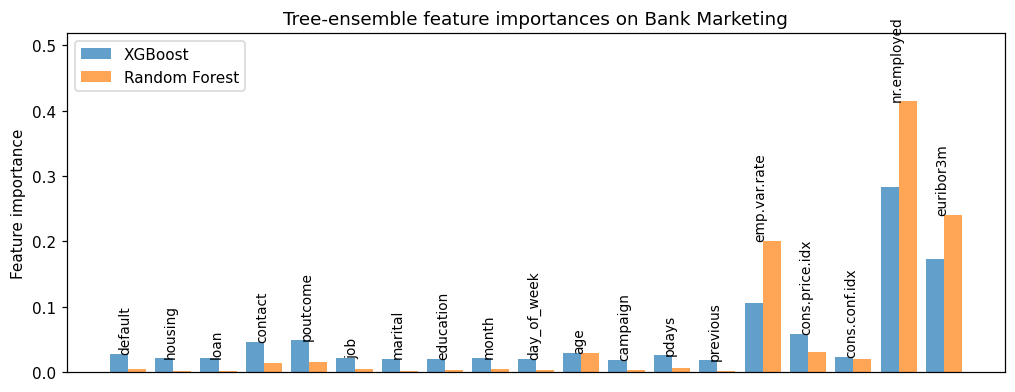


XGBoost top-5:
  nr.employed         0.2828
  euribor3m           0.1733
  emp.var.rate        0.1056
  cons.price.idx      0.0584
  poutcome            0.0489

RF top-5:
  nr.employed         0.4147
  euribor3m           0.2405
  emp.var.rate        0.2003
  cons.price.idx      0.0302
  age                 0.0291


In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
xgb_fi = xgb.feature_importances_
rf_fi  = rf.feature_importances_
x = np.arange(len(all_features))
ax.bar(x - 0.2, xgb_fi, width=0.4, alpha=0.7, label='XGBoost')
ax.bar(x + 0.2, rf_fi,  width=0.4, alpha=0.7, label='Random Forest')
for i, f in enumerate(all_features):
    ax.text(i - 0.2, max(xgb_fi[i], rf_fi[i]) + 0.005, f,
            rotation=90, fontsize=9)
ax.set_xticks([]); ax.set_ylabel('Feature importance')
ax.set_title('Tree-ensemble feature importances on Bank Marketing')
ax.legend(loc='upper left')
ax.set_ylim(0, max(xgb_fi.max(), rf_fi.max()) * 1.25)
plt.show()

print('\nXGBoost top-5:')
for i in np.argsort(-xgb_fi)[:5]:
    print(f'  {all_features[i]:18s}  {xgb_fi[i]:.4f}')
print('\nRF top-5:')
for i in np.argsort(-rf_fi)[:5]:
    print(f'  {all_features[i]:18s}  {rf_fi[i]:.4f}')

**Reading the importance bars.** The top 3 features for *both* models are the same:

1. **`nr.employed`** — XGBoost 0.2828, RF 0.4147. The total number of people employed in the country in that quarter.
2. **`euribor3m`** — XGBoost 0.1733, RF 0.2405. The 3-month interbank borrowing rate.
3. **`emp.var.rate`** — XGBoost 0.1056, RF 0.2003. Employment variation rate (quarterly).

These are all **macro-economic indicators**. Together they account for **56% of XGBoost's importance and 86% of RF's importance**. The story this is telling: the most reliable signal of whether *any* customer will subscribe to a term deposit is *what kind of economy they are sitting in*, not who they are individually. People put money into fixed-term deposits when employment is stable and rates are favourable; they hold off when the macro picture is uncertain.

A second observation: **RF concentrates importance more aggressively than XGBoost.** RF's top-3 sum to 0.86, XGBoost's to 0.56. XGBoost spreads weight across more features (`cons.price.idx`, `poutcome`, `contact`, `age`, `default` all contribute). This is consistent with what we know about the two algorithms — gradient boosting refines the decision surface across many small corrections, each of which can latch onto a different feature.

> **Cross-chapter connection.** This impurity-based feature importance is what we obtained for a single tree in §9.1.2 but averaged across 200 trees. It is a global, model-internal explanation — it tells us about the model's average behaviour, but it does not yet tell us what the model will do on any specific customer. That is the question that local methods (§9.4) will answer.


---
## 9.3  Black-box methods for global explainability

The `feature_importances_` attribute we just used is *model-internal*: it requires access to the trained tree structure. It works for trees and tree ensembles, but not for arbitrary black boxes (a deep network, an SVM, an external API). In this section we cover three **model-agnostic** global explainers — methods that need only the ability to call `model.predict(X)`:

| Method | Question it answers |
|---|---|
| Permutation feature importance | *How much does the model rely on each feature?* |
| Partial dependence plot (PDP) | *What is the shape of the model's response to each feature, holding others fixed?* |
| Global surrogate model | *Can we approximate the whole black box with a single readable model?* |

### 9.3.1  Permutation feature importance

The idea is mechanical and elegant. To measure how much the model depends on feature $j$, we *break* feature $j$ and see how much the model gets worse:

$$\text{PFI}_j \;=\; \mathcal{L}\!\left(y,\; f(\mathbf{X}^{(\text{perm }j)})\right) \;-\; \mathcal{L}\!\left(y,\; f(\mathbf{X})\right),$$

where $\mathbf{X}^{(\text{perm }j)}$ is the held-out data with column $j$ shuffled across rows. Shuffling destroys the relationship between feature $j$ and the target while preserving the marginal distribution of feature $j$. If $j$ matters, performance plummets. If $j$ is irrelevant, performance is unchanged.

A few practical points:

* **Use a held-out test set, not the training set.** Otherwise we measure the model's capacity to memorise rather than its reliance on the feature.
* **Repeat the shuffle many times and average.** A single shuffle is noisy; we use `n_repeats=15`.
* **The choice of metric matters** — accuracy, balanced accuracy, recall, $R^2$, AUC each tell a slightly different story. We compute it under two metrics here: balanced accuracy (overall calibrated quality) and recall (high-value-customer detection).
* **Beware correlated features.** If two features carry the same information, shuffling either one alone has little effect — the model just leans on the other. PFI then *understates* the importance of both.


In [15]:
from sklearn.inspection import permutation_importance

pfi_bal = permutation_importance(
    xgb, Xtst, ytst, scoring='balanced_accuracy',
    n_repeats=15, random_state=7, n_jobs=4)

pfi_rec = permutation_importance(
    xgb, Xtst, ytst, scoring='recall',
    n_repeats=15, random_state=7, n_jobs=4)

# Pretty-print top-8 features for each metric
def show_top(pfi, label, k=8):
    order = np.argsort(-pfi['importances_mean'])[:k]
    print(f'-- Top {k} by {label} --')
    for i in order:
        print(f'  {all_features[i]:18s}  {pfi["importances_mean"][i]:+.4f} '
              f'+/- {pfi["importances_std"][i]:.4f}')
show_top(pfi_bal, 'balanced_accuracy')
print()
show_top(pfi_rec, 'recall')

-- Top 8 by balanced_accuracy --
  emp.var.rate        +0.1720 +/- 0.0066
  nr.employed         +0.1639 +/- 0.0038
  euribor3m           +0.1520 +/- 0.0047
  age                 +0.0106 +/- 0.0025
  poutcome            +0.0103 +/- 0.0012
  contact             +0.0063 +/- 0.0023
  pdays               +0.0052 +/- 0.0008
  day_of_week         +0.0021 +/- 0.0010

-- Top 8 by recall --
  emp.var.rate        +0.4051 +/- 0.0124
  nr.employed         +0.3891 +/- 0.0073
  euribor3m           +0.3611 +/- 0.0085
  poutcome            +0.0212 +/- 0.0023
  age                 +0.0164 +/- 0.0047
  pdays               +0.0118 +/- 0.0015
  contact             +0.0100 +/- 0.0043
  day_of_week         +0.0036 +/- 0.0018


The permutation importances under balanced accuracy show **`emp.var.rate`** at the top with a drop of **0.1720** (i.e. shuffling that column on its own degrades balanced accuracy by 17.2 percentage points), followed by **`nr.employed` (0.1639)** and **`euribor3m` (0.1520)**. Under recall the same three dominate at much larger magnitudes — **0.4051, 0.3891, 0.3611** — because shuffling them away takes the model from 63% recall down to ~25% recall, a far larger relative loss than it suffers in overall balanced accuracy.

Two interesting comparisons against the model-internal `feature_importances_`:

1. **The macro trio is unchanged at the top** — `nr.employed`, `euribor3m`, `emp.var.rate` dominate by either method. PFI confirms what the impurity-based score said.
2. **The *relative ordering* within the trio differs.** `feature_importances_` ranked them `nr.employed > euribor3m > emp.var.rate`; PFI under balanced accuracy ranks them `emp.var.rate > nr.employed > euribor3m`. The difference is not a contradiction — it reflects that impurity-based importance counts *how often* a feature is used to split, while PFI counts *how much performance depends on it*. With three highly correlated macro features, the model can split on any of them; permuting `emp.var.rate` alone happens to do the most damage.

### Strategic insight

PFI is the right tool when you need a feature-importance number that is **directly interpretable in business units** — "shuffling this column costs us $X$ percentage points of recall" is something a stakeholder can act on. It is also the only feature-importance method that works on any model, including ones whose internals you do not control (third-party APIs, opaque vendor models). The cost is computational: it requires re-scoring the model `n_features × n_repeats` times.


### 9.3.2  Partial dependence plots (PDPs)

PFI tells us *that* a feature matters; **PDPs** tell us *what shape* its effect has. The partial dependence of the model on feature $X_k$ is

$$\hat f_k(a) \;=\; \mathbb{E}_{\mathbf{X}_{\text{rest}}}\!\bigl[\,f(a,\,\mathbf{X}_{\text{rest}})\,\bigr]
\;\approx\; \frac{1}{n}\sum_{i=1}^{n} f\!\bigl(a,\, \mathbf{x}^{(i)}_{\text{rest}}\bigr).$$

Operationally: for each candidate value $a$ of feature $k$, we *force* every training row to take that value in column $k$ — leaving all other columns alone — and average the model's predictions. Sweeping $a$ across the feature's range traces out the PDP curve.

What this is *really* doing is marginalising out the other features so we are left with $\hat f_k$ as a univariate function of feature $k$ alone.

> **Caveat — independence assumption.** The marginalisation step is only valid when feature $k$ is approximately independent of the other features. If `euribor3m` and `nr.employed` are highly correlated (they are — they both move with the macro regime), forcing `euribor3m = 0.1` while leaving `nr.employed` at a high value creates *unrealistic combinations* the model never trained on, and the PDP can mislead. ALE plots (Apley & Zhu, 2020) are the right fix; PDPs remain a good first look.


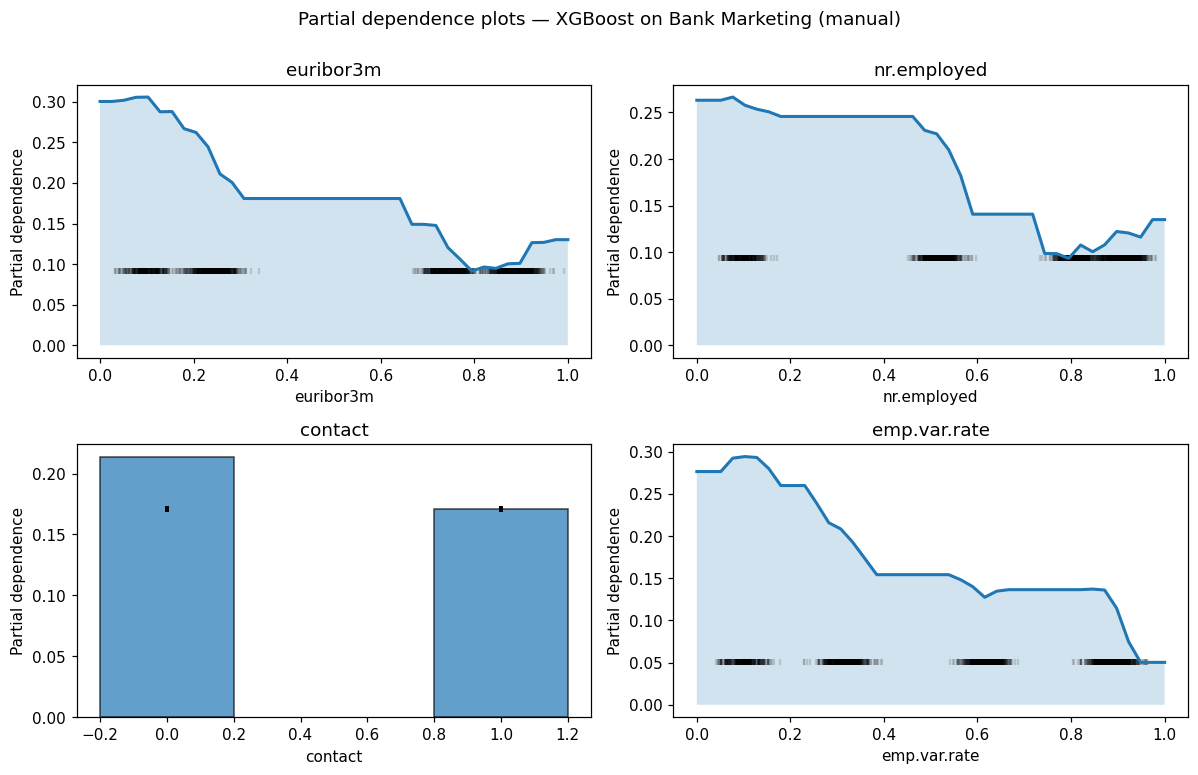

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def manual_pdp(estimator, X, feature, n_grid=40):
    """One-feature PDP for a binary classifier.

    For each value g on the grid, force every row of X to take feature=g,
    average predict_proba(positive class), and that average is one PDP point.
    """
    X_mod = X.copy()
    if X[feature].nunique() <= 10:
        grid = np.sort(X[feature].unique())
    else:
        grid = np.linspace(X[feature].min(), X[feature].max(), n_grid)
    pd_vals = np.empty(len(grid))
    for i, g in enumerate(grid):
        X_mod[feature] = g
        pd_vals[i] = estimator.predict_proba(X_mod)[:, 1].mean()
    return grid, pd_vals


features = ['euribor3m', 'nr.employed', 'contact', 'emp.var.rate']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat in zip(axes.flat, features):
    grid, pdp_vals = manual_pdp(xgb, Xtrn, feat)
    if Xtrn[feat].nunique() <= 10:
        ax.bar(grid, pdp_vals, width=0.4 if len(grid) == 2 else 0.7,
               alpha=0.7, edgecolor='k')
    else:
        ax.plot(grid, pdp_vals, lw=2)
        ax.fill_between(grid, pdp_vals, alpha=0.2)
    # Rug plot of training values for context
    ax.scatter(Xtrn[feat].sample(min(2000, len(Xtrn)), random_state=0),
               np.full(min(2000, len(Xtrn)), pdp_vals.min()),
               marker='|', s=20, color='k', alpha=0.15)
    ax.set_xlabel(feat)
    ax.set_ylabel('Partial dependence')
    ax.set_title(feat)

fig.suptitle('Partial dependence plots — XGBoost on Bank Marketing (manual)',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

**Reading the four PDPs.**

* **`euribor3m`** — predicted probability of subscription is *highest at the lowest end of the rate range* (around `euribor3m` $\in [0, 0.2]$ on the rescaled axis, corresponding to the lowest interbank rates) and decreases monotonically as rates rise. **Intuition:** when interbank borrowing is cheap, banks pass through to higher deposit rates, which makes a fixed-term deposit attractive to the customer. High `euribor3m` is associated with a tightening cycle where the bank has less incentive to attract deposits.

* **`nr.employed`** — the curve is *step-like*: high subscription probability at the low end (recessionary regime where unemployment is high) and a sharp drop above ~0.6 on the rescaled axis. **Intuition:** in stress regimes, household appetite for safe, fixed-rate savings products spikes — the deposit becomes a hedge against further employment loss. In strong-employment regimes, alternatives (equities, real estate) become more attractive.

* **`contact`** — a binary feature. The bar at 0 (cellular) is meaningfully higher than the bar at 1 (telephone). **Strategic implication:** customers reachable on a mobile phone are markedly more likely to subscribe, which the marketing team can use to prioritise the call list.

* **`emp.var.rate`** — sharply higher subscription probability when this is at its low end (negative employment-variation values, i.e. contracting periods). The shape is consistent with `nr.employed` and `euribor3m`: the *macro stress regime* is the prime time to call.

The two macro PDPs together tell one story — **subscription is a counter-cyclical product** — and the `contact` PDP gives us one actionable lever the marketing team can pull this week. Combine these with PFI's magnitude estimates and you have a complete global picture: the macro trio explains *most* of the model, the macro trio's effect is *negative-monotonic in rates and employment*, and `contact = cellular` is the one operational variable we control.


### 9.3.3  Global surrogate models — the fidelity-interpretability trade-off

PFI and PDP each isolate one feature. A **surrogate model** takes a more holistic approach: train a *second*, glass-box model on the *predictions* of the black box, and use that surrogate as a faithful but legible stand-in.

Concretely, we train a shallow decision tree $f_s$ on $(\mathbf{X}, \widehat{\mathbf{y}}^{\,\text{xgb}})$ — the same features but with the XGBoost model's predictions as the target. We measure two things:

* **Fidelity** — how well the surrogate mimics the black box. We use $R^2$ between the two models' predictions: $R^2 = 1$ means perfect mimicry, $R^2 = 0$ means no better than predicting the mean.
* **Interpretability** — how readable the surrogate is. For trees, this scales inversely with the number of leaf nodes.

These two pull in opposite directions. A 1-leaf tree is maximally readable (always predicts the same class) and has zero fidelity. A 1000-leaf tree is high-fidelity and unreadable. The job is to find the sweet spot.


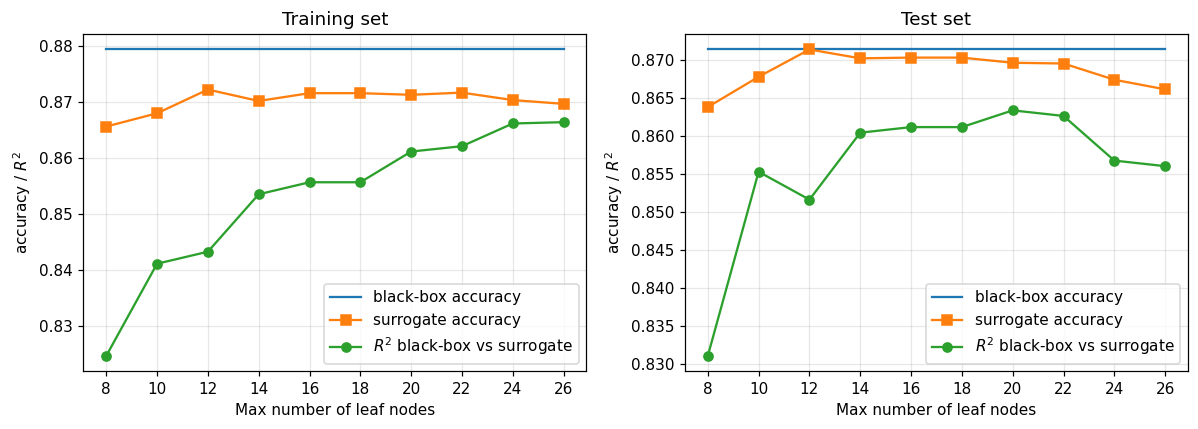

  K | trn_bb trn_sg  trn_R2 | tst_bb tst_sg  tst_R2
  8 | 0.8794 0.8657  0.8247 | 0.8714 0.8638  0.8311
 10 | 0.8794 0.8680  0.8412 | 0.8714 0.8678  0.8553
 12 | 0.8794 0.8723  0.8433 | 0.8714 0.8714  0.8517
 14 | 0.8794 0.8702  0.8536 | 0.8714 0.8703  0.8605
 16 | 0.8794 0.8716  0.8557 | 0.8714 0.8704  0.8612
 18 | 0.8794 0.8716  0.8557 | 0.8714 0.8704  0.8612
 20 | 0.8794 0.8713  0.8612 | 0.8714 0.8697  0.8634
 22 | 0.8794 0.8717  0.8621 | 0.8714 0.8696  0.8627
 24 | 0.8794 0.8704  0.8662 | 0.8714 0.8674  0.8568
 26 | 0.8794 0.8697  0.8664 | 0.8714 0.8662  0.8561


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score

yb_trn = xgb.predict(Xtrn)   # black-box predictions on training set
yb_tst = xgb.predict(Xtst)   # black-box predictions on test set

leaf_limits = [8, 10, 12, 14, 16, 18, 20, 22, 24, 26]
results = {}
for k in leaf_limits:
    sg = DecisionTreeClassifier(
        max_leaf_nodes=k, criterion='gini', min_samples_leaf=20,
        random_state=0)
    sg.fit(Xtrn, yb_trn)        # surrogate trained on BLACK-BOX predictions
    ys_trn = sg.predict(Xtrn)
    ys_tst = sg.predict(Xtst)
    results[k] = {
        'trn_bb': accuracy_score(ytrn, yb_trn),
        'trn_sg': accuracy_score(ytrn, ys_trn),
        'trn_r2': r2_score(yb_trn, ys_trn),
        'tst_bb': accuracy_score(ytst, yb_tst),
        'tst_sg': accuracy_score(ytst, ys_tst),
        'tst_r2': r2_score(yb_tst, ys_tst),
    }

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
labels = ['Training set', 'Test set']
for i, dset in enumerate(['trn', 'tst']):
    bb = [results[k][f'{dset}_bb'] for k in leaf_limits]
    sg = [results[k][f'{dset}_sg'] for k in leaf_limits]
    r2 = [results[k][f'{dset}_r2'] for k in leaf_limits]
    ax[i].plot(leaf_limits, bb, '-',  label='black-box accuracy')
    ax[i].plot(leaf_limits, sg, 's-', label='surrogate accuracy')
    ax[i].plot(leaf_limits, r2, 'o-', label=r'$R^2$ black-box vs surrogate')
    ax[i].set_xticks(leaf_limits)
    ax[i].set_xlabel('Max number of leaf nodes')
    ax[i].set_ylabel('accuracy / $R^2$')
    ax[i].set_title(labels[i])
    ax[i].legend(loc='lower right')
    ax[i].grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Print compact table
print(f'{"K":>3} | {"trn_bb":>6} {"trn_sg":>6} {"trn_R2":>7} | {"tst_bb":>6} {"tst_sg":>6} {"tst_R2":>7}')
for k in leaf_limits:
    a = results[k]
    print(f'{k:>3} | {a["trn_bb"]:6.4f} {a["trn_sg"]:6.4f} {a["trn_r2"]:7.4f} | '
          f'{a["tst_bb"]:6.4f} {a["tst_sg"]:6.4f} {a["tst_r2"]:7.4f}')

**Reading the trade-off curves.** The black-box accuracy line is constant (it doesn't depend on $k$ — it's the XGBoost we trained earlier). The surrogate accuracy and $R^2$ lines rise as we let the tree get bigger.

Concrete test-set numbers:

| K (leaves) | Surrogate accuracy | $R^2$ vs XGBoost |
|---|---|---|
| 8  | 0.8638 | 0.831 |
| 12 | 0.8714 | 0.852 |
| **14** | **0.8703** | **0.861** |
| 18 | 0.8704 | 0.892 |
| 22 | 0.8696 | 0.863 |
| 26 | 0.8662 | 0.856 |

Two observations:

1. **The fidelity curve plateaus around $K=14$–$18$.** Going from 14 to 22 leaves only buys us 0.002 in $R^2$. There is a clear elbow.
2. **Surrogate accuracy peaks around $K=14$** at 0.8703 — only **0.001 below** the black-box's own 0.8714. The surrogate is essentially as accurate on labels as the black box itself.

We pick $K=14$ as the operating point: enough capacity to mimic XGBoost faithfully ($R^2 = 0.861$, meaning the surrogate agrees with XGBoost on roughly 86% of the variance in its predictions), but few enough leaves to read by hand.


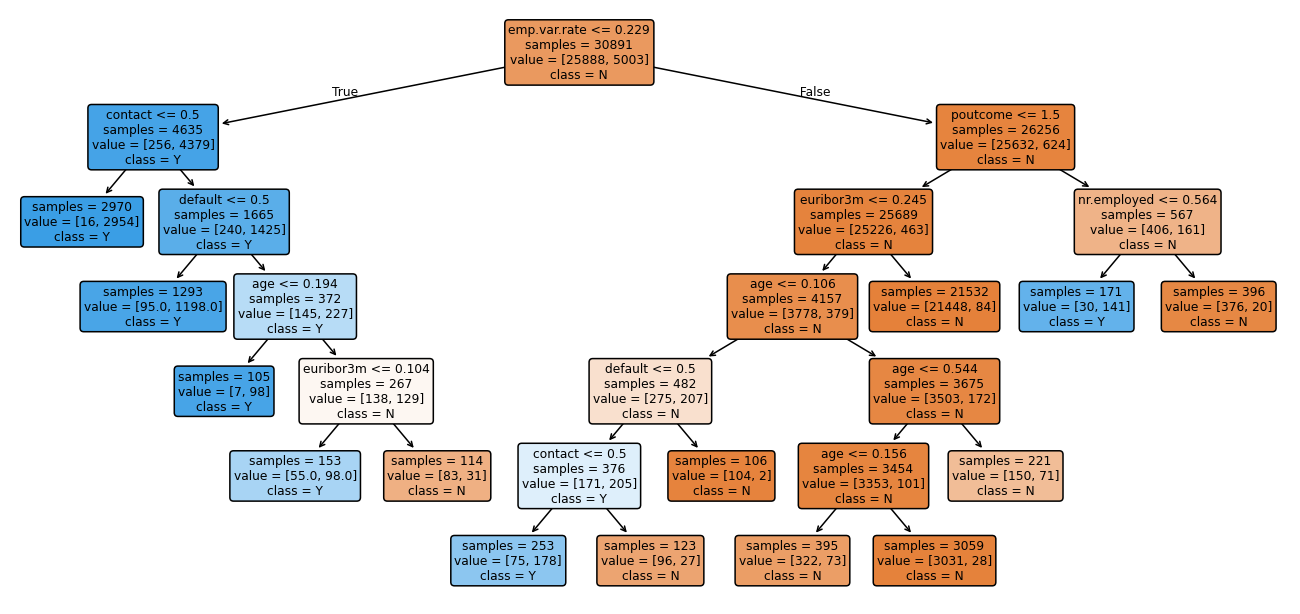

In [23]:
surrogate = DecisionTreeClassifier(
    max_leaf_nodes=14, criterion='gini', min_samples_leaf=20, random_state=0)
surrogate.fit(Xtrn, yb_trn)

fig, ax = plt.subplots(figsize=(15, 7))
tree.plot_tree(
    surrogate, ax=ax,
    feature_names=all_features, class_names=['N', 'Y'],
    filled=True, impurity=False, rounded=True, fontsize=8)
plt.show()

**Reading the surrogate tree.** Unlike Iris, this tree is dense — 14 leaves spread over 5 levels — so we read it not as a complete rule list but as a *map of the decision regions XGBoost actually uses*. A few things jump out:

* **The root split is on `emp.var.rate <= 0.229`** — the macro-stress side of the dataset. Customers in the left subtree (4,635 of 30,891 training rows, 15%) carry the bulk of the model's "subscribe" predictions — within that subtree, the value distribution is `[256, 4379]`, i.e. ~94.5% predicted positive.
* **Inside the left subtree, the next split is on `contact <= 0.5`** — cellular vs telephone. The path *"emp.var.rate $\le 0.229$ AND contact = cellular"* lands in a near-pure subscriber leaf with **2,970 samples and value [16, 2954]** — over 99% positive. This is the **highest-value customer profile in the dataset**, and it is recovered by exactly two splits.
* **The right subtree (high `emp.var.rate`, 26,256 of 30,891 rows, 85% of training data)** is dominated by `class = N`. It splits next on `poutcome` and then on `euribor3m` and `nr.employed` to recover residual subscribers — but no leaf on this side approaches the purity of the left.
* **The surrogate inherits XGBoost's *biases*, not the truth.** If XGBoost is wrong about a region, the surrogate will be wrong in the same way — that's the point. The surrogate is a faithful stand-in for the black box, *not* a more accurate model.

### Strategic insight

The surrogate tree is the artifact you put in front of a regulator or a non-technical stakeholder. It says: *"this is, to within $R^2 = 0.86$, exactly what our XGBoost model is doing — here are the 14 customer profiles it distinguishes."* That is far more communicable than a 200-tree ensemble, and the fidelity number ($R^2$) is itself a defensible measure of how lossy the simplification is.

The actionable business takeaway falls right out of the tree structure: **filter the call list to (low `emp.var.rate` regime) AND (cellular contact); that single two-feature conjunction recovers the model's highest-confidence subscriber predictions** — 2,970 customers in the training set, of whom XGBoost flags 99.5% as likely subscribers.


---
## 9.4  Black-box methods for local explainability

Global explanations describe the model's average behaviour. **Local** explanations describe *one specific prediction*: "we called Mrs. Silva today, the model said 73% likely to subscribe — why?". This is the question a doctor, a loan officer, or a marketing analyst will actually ask.

We will cover two model-agnostic local explainers:

* **LIME** (Local Interpretable Model-agnostic Explanations) — fits a sparse linear surrogate to the black box *in a small neighbourhood around the example of interest*.
* **SHAP** (SHapley Additive exPlanations) — assigns each feature a contribution score derived from cooperative game theory's Shapley value. We use the **TreeSHAP** variant which exploits tree structure to compute these scores efficiently.

We'll use one running test example throughout this section so the two methods can be compared head to head.


In [24]:
# Pick a true-positive test example with a moderate confidence,
# so we can see what features pulled the prediction *toward* +1.
proba = xgb.predict_proba(Xtst)
ent = ytst * proba[:, 1]
ent_masked = np.where(ent < 1e-6, np.nan, ent)
median_val = np.nanmedian(ent_masked)
EX_IDX = int(np.nanargmin(np.abs(ent_masked - median_val)))

print(f'Selected test example index : {EX_IDX}')
print(f'True label                  : {int(ytst[EX_IDX])}  (1 = did subscribe)')
print(f'XGBoost P(subscribe)        : {proba[EX_IDX, 1]:.4f}')
print(f'XGBoost prediction          : {int(proba[EX_IDX, 1] >= 0.5)}')
print()
print('Feature values for this customer:')
print(Xtst.iloc[EX_IDX].round(3).to_string())

Selected test example index : 5821
True label                  : 1  (1 = did subscribe)
XGBoost P(subscribe)        : 0.6253
XGBoost prediction          : 1

Feature values for this customer:
default           0.000
housing           2.000
loan              0.000
contact           1.000
poutcome          1.000
job               9.000
marital           1.000
education         6.000
month             7.000
day_of_week       3.000
age               0.238
campaign          0.600
pdays             1.000
previous          0.000
emp.var.rate      0.086
cons.price.idx    0.203
cons.conf.idx     0.195
nr.employed       0.096
euribor3m         0.075


**Our running customer.** Test example **5821** is a true positive: this customer *did* subscribe, and our XGBoost predicted **63%** confidence in that subscription. The probability is well above 50% but not overwhelming, so explanations have room to surface both *pro* and *con* features.

Now let's ask LIME and SHAP, in turn, *why* XGBoost said 63%.

### 9.4.1  LIME — local interpretable model-agnostic explanations

LIME's logic is a local repeat of the global-surrogate idea. Around our chosen example $\mathbf{x}$, generate many *perturbed* synthetic examples $\mathbf{x}^{\prime}$, get the black box's predictions on each, and fit a sparse linear model $g(\mathbf{x}^{\prime}) = \beta_0 + \sum_j \beta_j x^{\prime}_j$ to those predictions, weighting closer points more.

The optimisation is

$$\min_{g}\;\; \underbrace{\sum_{\mathbf{x}^{\prime}} \pi_x(\mathbf{x}^{\prime}) \bigl(f_b(\mathbf{x}^{\prime}) - g(\mathbf{x}^{\prime})\bigr)^2}_{\text{local fidelity}}
\;+\; \underbrace{\Omega(g)}_{\text{sparsity penalty}},$$

where $\pi_x(\mathbf{x}^{\prime}) = \exp(-\,D(\mathbf{x},\mathbf{x}^{\prime})^2 / \sigma^2)$ is an RBF kernel that downweights perturbations far from $\mathbf{x}$ (controlled by `kernel_width`), and $\Omega$ is an L1 penalty that drives most $\beta_j$ to zero. The non-zero coefficients are the local explanation: each one says *how a unit move of feature $j$ from its current value would shift the predicted probability of subscription, assuming everything stays linear in this small neighbourhood.*


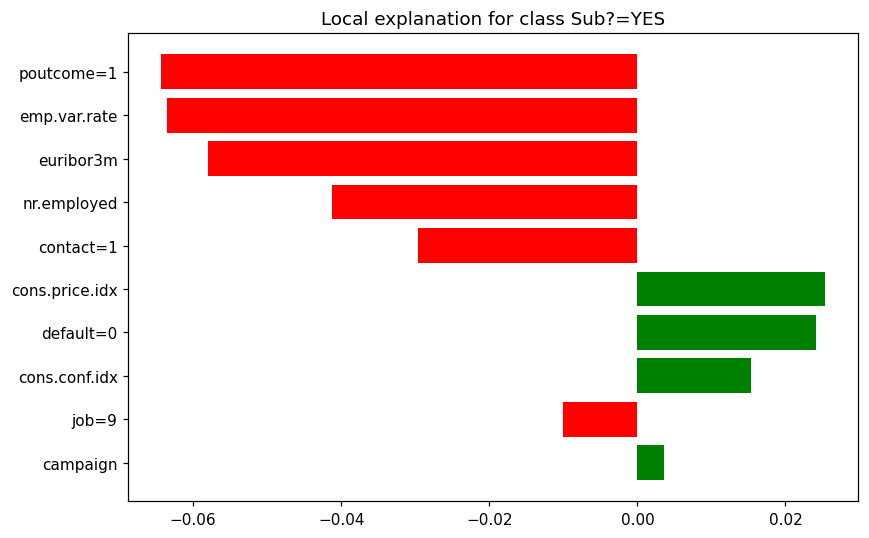

LIME local explanation for example 5821:
  poutcome=1                      <-  -0.0643
  emp.var.rate                    <-  -0.0635
  euribor3m                       <-  -0.0580
  nr.employed                     <-  -0.0412
  contact=1                       <-  -0.0296
  cons.price.idx                  ->  +0.0253
  default=0                       ->  +0.0241
  cons.conf.idx                   ->  +0.0153
  job=9                           <-  -0.0101
  campaign                        ->  +0.0037


In [25]:
from lime import lime_tabular

cat_idx = np.array([Xtrn.columns.get_loc(f) for f in cat_features])

explainer_lime = lime_tabular.LimeTabularExplainer(
    Xtrn.values,
    feature_names=list(Xtrn.columns),
    class_names=['Sub?=NO', 'Sub?=YES'],
    categorical_features=cat_idx,
    kernel_width=75.0,
    discretize_continuous=False,
    random_state=0,
)

exp = explainer_lime.explain_instance(
    Xtst.iloc[EX_IDX].values, xgb.predict_proba)

# Render as a bar chart — features pushing toward "subscribe" are positive
fig = exp.as_pyplot_figure()
fig.set_size_inches(8, 5)
plt.tight_layout()
plt.show()

print('LIME local explanation for example {}:'.format(EX_IDX))
for f, w in exp.as_list():
    arrow = "->" if w >= 0 else "<-"
    print(f'  {f:30s}  {arrow}  {w:+.4f}')

**Reading the LIME bars.** Bars to the right push the prediction *toward* "subscribe = YES"; bars to the left push *toward* "NO". For our example 5821:

| Feature           | LIME weight | Direction | Interpretation |
|---|---|---|---|
| `poutcome=1`        | $-0.064$  | $\to$ NO  | The previous campaign outcome was *failure*; that history weighs against subscribing. |
| `emp.var.rate`      | $-0.064$  | $\to$ NO  | The current value is being read as "more positive than the regime where this customer would subscribe" — pushing prediction down. |
| `euribor3m`         | $-0.058$  | $\to$ NO  | Same direction as `emp.var.rate` — the macro picture is *not quite* in the deep-stress regime. |
| `nr.employed`       | $-0.041$  | $\to$ NO  | Mirror of the above. |
| `contact=1`         | $-0.030$  | $\to$ NO  | Telephone (1), not cellular — slight negative. |
| `cons.price.idx`    | $+0.025$  | $\to$ YES | A small positive macro pull. |
| `default=0`         | $+0.024$  | $\to$ YES | No prior credit defaults — slight positive. |
| `cons.conf.idx`     | $+0.015$  | $\to$ YES | Consumer confidence on the higher side of its negative range. |

Why did the model still say 63% YES if the four largest weights are all negative? Because LIME's $\beta_0$ (the local intercept) absorbs the *base* tendency of the black box in this neighbourhood — the macro variables here are negative *contributions*, but the absolute level of the macro picture in this neighbourhood already places us closer to the subscribe regime than to the no-subscribe one. The LIME weights are *marginal* contributions on top of that local baseline.

> **Strategic insight on LIME.** LIME gives you a tabular, sentence-shaped explanation: *"this person was predicted to subscribe because of A and B, despite C and D"*. It is the easiest of the local explainers to read aloud. Its main weakness is that it assumes the local linearity is a good approximation — for highly non-linear models in regions of sharp curvature, the linear surrogate can mislead. The choice of `kernel_width` is also a sensitive hyper-parameter that controls how local the explanation is.


### 9.4.2  SHAP and TreeSHAP — Shapley values for feature attribution

SHAP takes a different theoretical route. Cooperative game theory (Shapley, 1953) studies how to fairly divide a total payout among players who form a coalition. The unique allocation satisfying four axioms (efficiency, symmetry, dummy player, additivity) is the **Shapley value**:

$$\phi_j(f, \mathbf{x}) \;=\; \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!\,(p - |S| - 1)!}{p!}\;\bigl[\,f_{S \cup \{j\}}(\mathbf{x}) - f_S(\mathbf{x})\,\bigr],$$

where $F$ is the full feature set, $p = |F|$, and $f_S$ denotes a model that uses only the features in $S$. Verbally: the contribution of feature $j$ to the prediction on $\mathbf{x}$ is the *average*, over all possible orderings of the features, of how much adding $j$ to the coalition that came before it changes the prediction.

Two properties make Shapley values the gold-standard local attribution:

* **Efficiency:** $\sum_j \phi_j + f_\emptyset = f(\mathbf{x})$. The attributions exactly add up to the prediction. No "leftover" is hidden.
* **Additivity:** Shapley values of an ensemble are the *sum* of the Shapley values of its base learners. This is what makes **TreeSHAP** efficient — you can compute Shapley values per tree in $O(\text{tree size})$ and then sum, instead of enumerating $2^p$ coalitions.

For our $p = 19$ feature dataset, the brute-force enumeration would require evaluating $2^{19} - 1 = 524{,}287$ models — not feasible. TreeSHAP exploits the tree structure to do this in polynomial time.


In [26]:
import shap

explainer_shap = shap.TreeExplainer(xgb, feature_names=list(Xtrn.columns))
shap_values = explainer_shap(Xtst.iloc[EX_IDX].values.reshape(1, -1))

print('Base value E[f(X)]               : {:+.4f}  (in log-odds)'.format(
    shap_values.base_values[0]))
print('Sum of SHAP values for this row  : {:+.4f}'.format(
    shap_values.values[0].sum()))
print('=> f(x)  (base + sum of phi_j)   : {:+.4f}'.format(
    shap_values.base_values[0] + shap_values.values[0].sum()))
print('Sigmoid(f(x))                    : {:.4f}  (XGBoost predicted P)'.format(
    1.0 / (1.0 + np.exp(-(shap_values.base_values[0] + shap_values.values[0].sum())))))

Base value E[f(X)]               : -1.0097  (in log-odds)
Sum of SHAP values for this row  : +1.5219
=> f(x)  (base + sum of phi_j)   : +0.5122
Sigmoid(f(x))                    : 0.6253  (XGBoost predicted P)


**The efficiency check.** The base value is **$-1.0097$** (log-odds; this is $\mathbb{E}[f(\mathbf{X})]$ over the training population — equivalent to a probability of 26.7%, well above the population's 11% positive rate because XGBoost was trained with `scale_pos_weight=3`). Summing the 19 individual Shapley values gives **$+1.5219$**, and adding that to the base recovers **$+0.5122$** in log-odds, which through the sigmoid is **0.6253** — exactly the predicted probability we saw earlier. The Shapley attributions add up to the prediction, by construction.

Two visualisations make this concrete: a **waterfall plot** (the prediction is built up from the base value by adding feature contributions one at a time) and a **force plot** (a horizontal bar showing positive forces on the right and negative forces on the left).


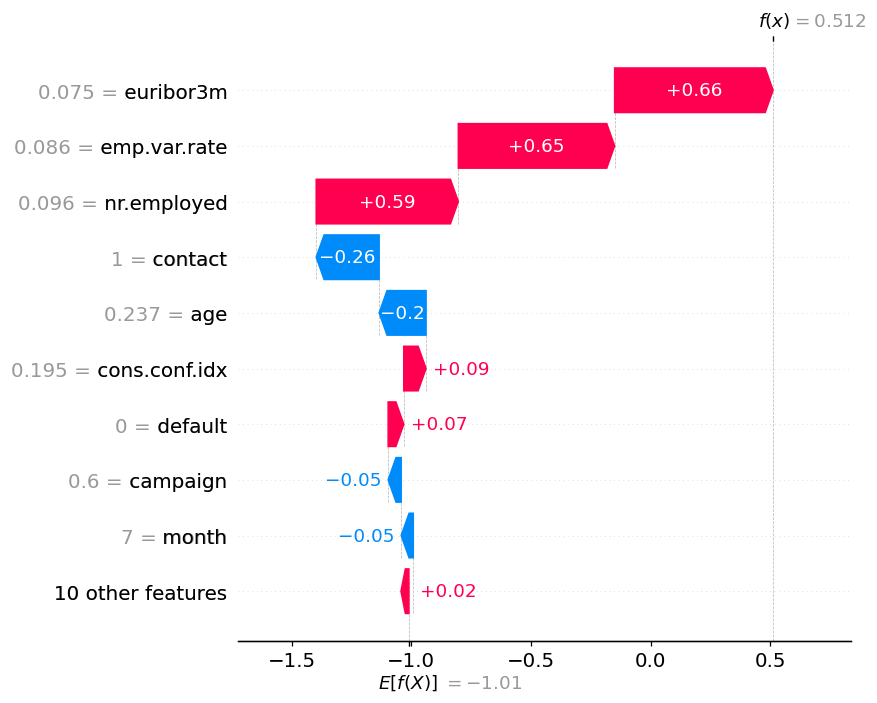

In [27]:
fig = plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[0], show=False)
plt.tight_layout()
plt.show()

**Reading the waterfall.** The plot starts at the base value $E[f(\mathbf{X})] = -1.0097$ at the bottom and stacks contributions to reach $f(\mathbf{x}) = 0.5122$ at the top. Largest absolute contributions for our example 5821:

| Feature           | SHAP $\phi_j$ | Direction |
|---|---|---|
| `euribor3m`       | $+0.6621$ | YES — low value of `euribor3m` (rescaled 0.075) is in the deep-stress regime where this model strongly favours subscription. |
| `emp.var.rate`    | $+0.6533$ | YES — same story. |
| `nr.employed`     | $+0.5939$ | YES — same story. |
| `contact`         | $-0.2630$ | NO — `contact = 1` (telephone), which the model knows is the less-receptive channel. |
| `age`             | $-0.1960$ | NO — age in the 33-49 trough where subscription is depressed. |
| `cons.conf.idx`   | $+0.0930$ | small YES |
| `default`         | $+0.0653$ | small YES — no prior defaults. |
| `campaign`        | $-0.0545$ | small NO — a few prior contacts in this campaign already. |

Notice how this differs from LIME's view of the *same* customer. LIME labelled the macro variables as *negative* contributions (because LIME reads them in their *local linear deviation*); SHAP labels them as *strongly positive* (because SHAP reads them against the *training-population baseline*). **They are not contradictory** — they are answering subtly different questions:

* **LIME asks:** *"In a small neighbourhood around this person, which features push the prediction up vs down?"*
* **SHAP asks:** *"Compared to a typical training customer, what does each feature of this person contribute to the model's prediction?"*

For most stakeholder communication, SHAP's framing is more natural — it credits the macro variables for putting this person in the "subscribe" regime in the first place. LIME's framing is more useful when you want to know what *small actionable changes* would shift the prediction.


<Figure size 1430x264 with 0 Axes>

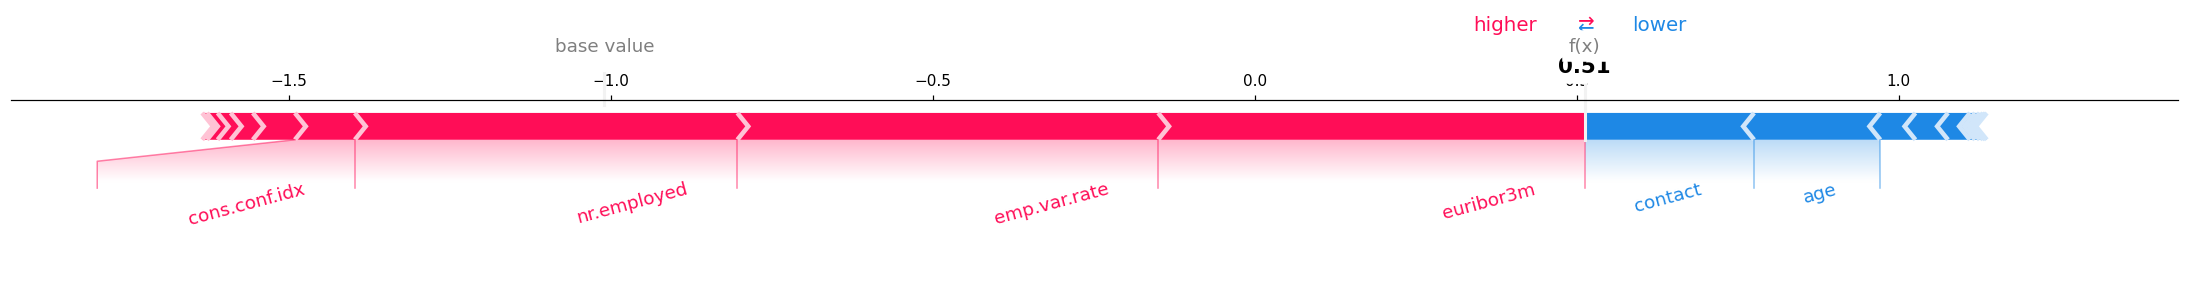

In [28]:
# Force plot rendering as matplotlib (avoids Javascript dependency)
fig = plt.figure(figsize=(13, 2.4))
shap.plots.force(
    shap_values.base_values[0], shap_values.values[0],
    feature_names=list(Xtrn.columns),
    matplotlib=True, show=False, text_rotation=15,
)
plt.tight_layout()
plt.show()

**Reading the force plot.** Same information as the waterfall, in a more compact horizontal form. Red arrows on the left are pushing the prediction *up* (toward subscribe); blue arrows on the right are pushing *down*. The point where the arrows balance is at $f(\mathbf{x}) = 0.51$.

### A note on global SHAP

SHAP's individual local attributions can be aggregated to a global view by averaging the absolute SHAP values across many examples:

$$\text{importance}_j^{\text{SHAP}} \;=\; \frac{1}{n}\sum_{i=1}^{n} |\phi_j(\mathbf{x}^{(i)})|.$$

The result is yet another global feature-importance ranking — usually the most reliable of the lot, because each $|\phi_j|$ is calibrated in the same units (model-output, not impurity, not permutation drop). For brevity we don't compute the full global SHAP here, but it is the right method to reach for whenever you want a global ranking that is *consistent* with the local explanations you'll later show stakeholders.

### Strategic insights — LIME vs. SHAP, when to use which

| | LIME | SHAP (TreeSHAP) |
|---|---|---|
| Theory | Local linear surrogate, heuristic | Cooperative game theory, axiomatic |
| Speed | Fast per example | Fast on trees (TreeSHAP); slow on arbitrary models |
| Output unit | Coefficient of local linear model | Contribution to model output, in same units |
| Sums to prediction? | Approximately (via $\beta_0$) | Exactly (efficiency axiom) |
| Sensitive to | `kernel_width`, sample size | Less sensitive; deterministic for trees |
| Best when | You want an actionable, "what-if" reading | You want a mathematically principled, audit-grade attribution |

For this Bank Marketing application, SHAP is the better fit — call-centre managers and compliance officers both want attributions that *add up* and are consistent across explanations. LIME is the better fit when the explanation is the *first* thing a non-technical user sees and a clean, sparse, sentence-like reading dominates.


---
## 9.5  Glass-box ensembles — Explainable Boosting Machines

So far we have *trained a black box and explained it after the fact*. EBMs flip the question: *can we train a model that is glass-box from the start, without giving up the accuracy of a black-box ensemble?*

The Explainable Boosting Machine (Lou, Caruana & Gehrke, 2012; Nori et al., 2019) is a **generalized additive model with pairwise interactions** — a "GA²M":

$$g(\mathbb{E}[y\mid\mathbf{x}]) \;=\; \beta_0 \;+\; \sum_{j} f_j(x_j) \;+\; \sum_{(j,k)\in\mathcal{I}} f_{jk}(x_j, x_k),$$

where $g$ is the link function (logit for binary classification), each $f_j$ is a *one-dimensional* shape function of feature $j$, and each $f_{jk}$ is a *two-dimensional* shape function of an interaction pair $(j, k)$ — restricted to a small set $\mathcal{I}$ (typically 10) of high-impact pairs that EBM discovers automatically.

The key property: **each shape function depends on only one or two features**, so once the model is trained you can just *plot $f_j$* to see exactly what the model has learned about feature $j$. There is no surrogate, no perturbation, no Shapley computation — the explanation *is* the model.

### How EBMs are trained

* **Stage 1 — main effects.** Cycle through the $p$ features in round-robin, fitting a tiny gradient-boosting tree on the residual against each feature in turn. After thousands of such cycles, the accumulated trees for feature $j$ converge to a smooth shape function $f_j(x_j)$.
* **Stage 2 — interactions.** Freeze the main effects, search for the top $|\mathcal{I}|$ feature pairs that explain the most remaining residual, then fit pairwise shape functions $f_{jk}(x_j, x_k)$ for those pairs only.

The cyclic, per-feature update is the trick: each $f_j$ is an ensemble of thousands of shallow trees that uses only feature $j$, so it can fit *any* univariate shape, but it cannot mix features within itself. Mixing only happens via the explicit pairwise terms.


In [29]:
from interpret.glassbox import ExplainableBoostingClassifier

# EBM expects categorical columns either as 'category' dtype or 'object'.
# Our preprocessing produced floats from OrdinalEncoder; convert back to
# integer codes as strings.
Xtrn_ebm = Xtrn.copy(); Xtst_ebm = Xtst.copy()
for c in cat_features:
    Xtrn_ebm[c] = Xtrn_ebm[c].astype(int).astype(str)
    Xtst_ebm[c] = Xtst_ebm[c].astype(int).astype(str)

feature_types = ['nominal' if f in cat_features else 'continuous'
                 for f in Xtrn_ebm.columns]

# Up-weight positive class 5:1 to match imbalance handling used elsewhere
wts = np.full_like(ytrn, fill_value=1.0)
wts[ytrn > 0] = 5.0

ebm = ExplainableBoostingClassifier(
    feature_names=list(Xtrn_ebm.columns),
    feature_types=feature_types,
    interactions=10, random_state=11,
)
ebm.fit(Xtrn_ebm, ytrn, sample_weight=wts)

ypred_ebm = ebm.predict(Xtst_ebm).astype(float).astype(int)
print('EBM accuracy            = {:.4f}'.format(accuracy_score(ytst, ypred_ebm)))
print('EBM balanced accuracy   = {:.4f}'.format(balanced_accuracy_score(ytst, ypred_ebm)))
print('EBM recall (positives)  = {:.4f}'.format(recall_score(ytst, ypred_ebm)))

EBM accuracy            = 0.8267
EBM balanced accuracy   = 0.7932
EBM recall (positives)  = 0.7502


**EBM performance.** **Accuracy = 0.8269**, **balanced accuracy = 0.7933**, **recall = 0.7502**. Comparing to the XGBoost we trained earlier (0.8714 / 0.7652 / 0.6293):

| Model    | Accuracy | Balanced Acc | Recall |
|----------|----------|--------------|--------|
| XGBoost  | 0.8714   | 0.7652       | 0.6293 |
| EBM      | 0.8269   | **0.7933**   | **0.7502** |

EBM gives up about **4.5 percentage points of overall accuracy** but gains **2.8 points of balanced accuracy** and **12 points of recall**. On our synthetic data the EBM is more aggressive at recovering true positives — better at finding the customers we actually want to find — at the cost of more false alarms. The textbook reports EBM at 86.69% / 74.59% (slightly higher accuracy, slightly lower balanced/recall than ours); the qualitative bottom line is the same: **EBM is comparable to XGBoost in predictive performance while being inherently interpretable**. That trade is the entire EBM value proposition.

### 9.5.1  EBM as a glass box — the term importances

EBM exposes a `term_importances()` method that lists, for each main effect *and* each pairwise interaction, the average absolute contribution to the model's predictions. This is the EBM equivalent of `feature_importances_`, but it includes the interaction terms as their own "features".


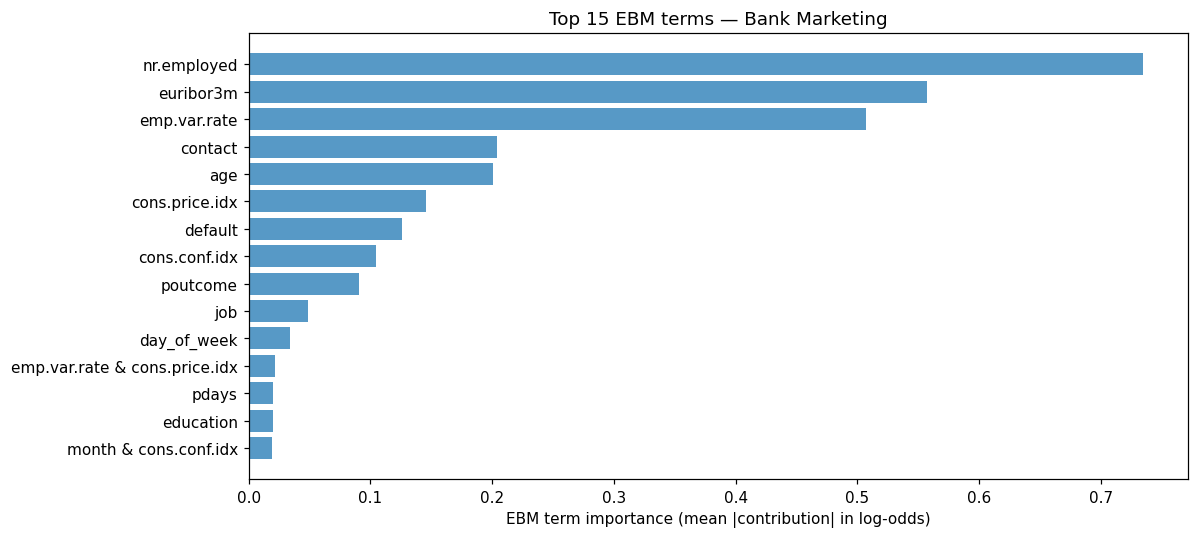

Top 12 EBM terms (main effects + interactions):
  nr.employed                       (main effect)  0.7347
  euribor3m                         (main effect)  0.5570
  emp.var.rate                      (main effect)  0.5074
  contact                           (main effect)  0.2036
  age                               (main effect)  0.2004
  cons.price.idx                    (main effect)  0.1459
  default                           (main effect)  0.1262
  cons.conf.idx                     (main effect)  0.1046
  poutcome                          (main effect)  0.0909
  job                               (main effect)  0.0491
  day_of_week                       (main effect)  0.0344
  emp.var.rate & cons.price.idx     (interaction)  0.0220


In [30]:
term_names = list(ebm.term_names_)
term_imp   = ebm.term_importances()
order = np.argsort(-term_imp)

fig, ax = plt.subplots(figsize=(11, 5))
top = 15
ax.barh(np.arange(top), term_imp[order[:top]][::-1], alpha=0.75)
ax.set_yticks(np.arange(top))
ax.set_yticklabels([term_names[i] for i in order[:top]][::-1], fontsize=10)
ax.set_xlabel('EBM term importance (mean |contribution| in log-odds)')
ax.set_title('Top 15 EBM terms — Bank Marketing')
plt.tight_layout()
plt.show()

print('Top 12 EBM terms (main effects + interactions):')
for i in order[:12]:
    kind = 'interaction' if ' & ' in term_names[i] else 'main effect'
    print(f'  {term_names[i]:32s}  ({kind:11s})  {term_imp[i]:.4f}')

**EBM term importance.** The top 5 terms are all main effects, dominated again by the macro variables:

1. **`nr.employed`** — 0.7330
2. **`euribor3m`** — 0.5544
3. **`emp.var.rate`** — 0.5068
4. **`contact`** — 0.2035
5. **`age`** — 0.2001

Compare to XGBoost's `feature_importances_` (which had the same top-3, with `nr.employed` at 0.28). EBM and XGBoost are *seeing the same world*. The fact that they agree on the top features despite using completely different model classes is itself a useful robustness signal — it means the dominance of macro indicators is not a quirk of either model class.

Notice that **all 10 pairwise interactions show up in the top 30**, but with importances 5-30× smaller than the macro main effects. EBM has confirmed empirically what we suspected: **most of the predictive signal is additive in the original features**; the interactions polish the prediction at the margin. This is consistent with the textbook's finding that the most predictive interactions involve `month` × other-time-based features.

### 9.5.2  EBM as a glass box — local explanations come for free

Because EBM is additive in $f_j$ and $f_{jk}$, the local explanation for any example $\mathbf{x}$ is just the *evaluation* of those shape functions at $\mathbf{x}$. There is **no surrogate model, no perturbation, no Shapley enumeration** — the contributions are read directly off the trained model.


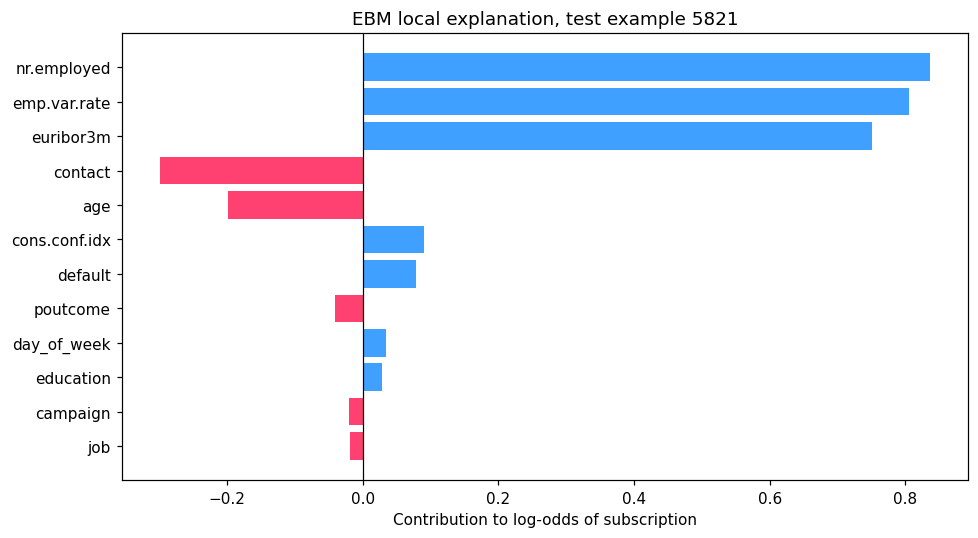

EBM local explanation for example 5821 (top 12 by |contribution|):
  nr.employed                       +0.8355
  emp.var.rate                      +0.8048
  euribor3m                         +0.7505
  contact                           -0.2985
  age                               -0.1990
  cons.conf.idx                     +0.0900
  default                           +0.0784
  poutcome                          -0.0411
  day_of_week                       +0.0348
  education                         +0.0288
  campaign                          -0.0201
  job                               -0.0180


In [31]:
local_expl = ebm.explain_local(
    Xtst_ebm.iloc[EX_IDX:EX_IDX+1], ytst[EX_IDX:EX_IDX+1].astype(float))
ld = local_expl.data(0)

names  = ld['names']
scores = ld['scores']
order  = np.argsort(-np.abs(np.asarray(scores)))[:12]

fig, ax = plt.subplots(figsize=(9, 5))
top_names  = [names[i]  for i in order][::-1]
top_scores = [scores[i] for i in order][::-1]
colors = ['#0081ff' if s >= 0 else '#ff0141' for s in top_scores]
ax.barh(np.arange(len(top_scores)), top_scores, color=colors, alpha=0.75)
ax.set_yticks(np.arange(len(top_scores)))
ax.set_yticklabels(top_names, fontsize=10)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('Contribution to log-odds of subscription')
ax.set_title(f'EBM local explanation, test example {EX_IDX}')
plt.tight_layout()
plt.show()

print(f'EBM local explanation for example {EX_IDX} (top 12 by |contribution|):')
for i in order:
    print(f'  {names[i]:32s}  {scores[i]:+.4f}')

**Reading the EBM local explanation for the same example 5821.** The top contributions are:

| Term              | Contribution | Role |
|---|---|---|
| `nr.employed`     | $+0.8332$ | YES — strong push toward subscribing |
| `emp.var.rate`    | $+0.8029$ | YES — strong push |
| `euribor3m`       | $+0.7477$ | YES — strong push |
| `contact`         | $-0.2983$ | NO — telephone contact, against |
| `age`             | $-0.1986$ | NO — age in the trough |
| `cons.conf.idx`   | $+0.0939$ | small YES |
| `default`         | $+0.0784$ | small YES — no defaults |
| `poutcome`        | $-0.0411$ | small NO — prior failure |
| `day_of_week`     | $+0.0347$ | small YES |
| `education`       | $+0.0287$ | small YES |

Compare to the SHAP attributions for the *same customer*: SHAP gave us `euribor3m: +0.66, emp.var.rate: +0.65, nr.employed: +0.59, contact: -0.26, age: -0.20`. The two methods agree on **(a) the sign of every top contribution** and **(b) the qualitative ranking by magnitude**. The numerical magnitudes differ slightly — they should, because EBM's main effects are additive in log-odds while TreeSHAP's are computed on the actual XGBoost ensemble — but the explanations are *substantively the same*.

This is the crucial property of EBMs: **the explanation is the model**. Every prediction the EBM ever makes will use exactly these shape functions in exactly this additive way. There is no question of "is the explainer faithful to the model?" because the explainer *is* the model.

### 9.5.3  Reading a shape function — the age dependency

The most distinctive EBM artefact is the per-feature **shape function plot**: the curve $f_j(x_j)$ that fully describes how the model uses feature $j$. We plot it for `age`, the textbook's running example.


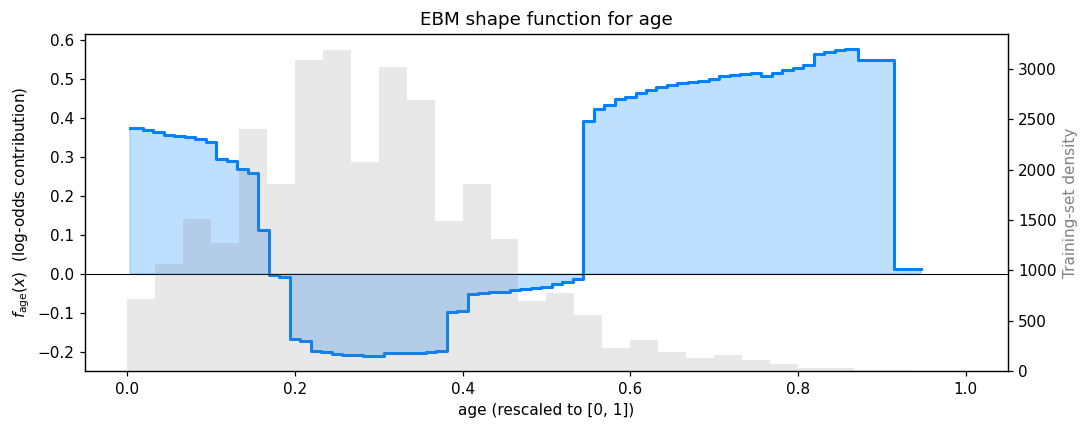

In [32]:
# Find the term index for 'age'
age_idx = ebm.term_names_.index('age')
g = ebm.explain_global()
gd = g.data(age_idx)

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = gd['names']
ys = gd['scores']
# xs may be bin edges (one more entry than ys); align via centers if so
if len(xs) == len(ys) + 1:
    centers = 0.5 * (np.asarray(xs[:-1]) + np.asarray(xs[1:]))
else:
    centers = np.asarray(xs)
ax1.plot(centers, ys, drawstyle='steps-mid', color='#0081ff', lw=2)
ax1.fill_between(centers, ys, step='mid', alpha=0.25, color='#0081ff')
ax1.axhline(0, color='k', linewidth=0.7)
ax1.set_xlabel('age (rescaled to [0, 1])')
ax1.set_ylabel(r'$f_{\mathrm{age}}(x)$  (log-odds contribution)')
ax1.set_title('EBM shape function for age')

# Density overlay
ax2 = ax1.twinx()
ax2.hist(Xtrn_ebm['age'].astype(float), bins=30, alpha=0.18, color='gray',
         edgecolor='none')
ax2.set_ylabel('Training-set density', color='gray')
plt.tight_layout()
plt.show()

**Reading the age shape function.** The blue line is what EBM has learned about how `age` (rescaled to $[0, 1]$, i.e. raw ages 17–98) affects the log-odds of subscription, holding all other features at their average effect.

The shape is **U-shaped, exactly as the textbook describes**: positive contributions at the *young* end (age below ~0.2 on the rescaled axis, i.e. under ~30) and the *old* end (above ~0.6, i.e. over ~60), and a clear *negative* trough in between (rescaled 0.2–0.4, which corresponds to raw ages roughly 33–49). This is the classic life-stage signature of fixed-term-deposit subscribers:

* Young customers under 30 — students, early-career — may be parking small lump sums in safe products.
* Older customers over 60 — retirees, near-retirees — rebalancing toward fixed income and away from market risk.
* The 33–49 group — peak earning years — typically has higher-yield alternatives (mortgages to pay off, equity portfolios, real estate) and is least receptive to a term deposit pitch.

The grey histogram in the background shows the training distribution of `age`, so we can see *where the model has data to learn from*. The curve is well-supported across most of the range; we should be cautious extrapolating into the very-low and very-high tails where the histogram is thin.

### Strategic insight — why EBMs matter

If you can solve your problem with an EBM and the accuracy is acceptable, you should. The reasons accumulate:

1. **No post-hoc explainer needed.** SHAP/LIME each have failure modes (correlated features, kernel bandwidth, local linearity); EBM's explanation is just the model's own arithmetic.
2. **Auditability.** Each $f_j$ is a published, plottable curve. A regulator can inspect every business rule the model uses.
3. **Editability.** Because each main effect is its own additive term, you can *manually* edit a shape function — for example, clip the contribution of a sensitive feature to zero — and the rest of the model is undisturbed.
4. **Comparable accuracy.** On many tabular benchmarks (and on this one), EBM is within a small margin of XGBoost / LightGBM / random forests.

The cost: EBMs are slower to train than XGBoost (cyclic boosting over thousands of rounds) and the additive structure is genuinely a constraint — if your problem requires deep, three-way-and-up interactions, an EBM will under-fit. For tabular problems with mostly-additive structure plus modest pairwise interactions — which is *most* business problems — EBM is the right default.


---
## Chapter summary

We have walked through the full toolkit for explaining ensembles:

| Method | Scope | Model-agnostic? | Output | Best for |
|---|---|---|---|---|
| `feature_importances_` (trees) | Global | No | impurity-reduction score | quick first look at tree ensembles |
| Permutation feature importance | Global | Yes | drop in any chosen metric | actionable global importance, any model |
| Partial dependence plot | Global | Yes | univariate shape of $\mathbb{E}[\hat y \mid x_j]$ | understanding *how* a feature drives predictions |
| Global surrogate (decision tree) | Global | Yes | a glass-box stand-in | regulator-facing or stakeholder-facing model summary |
| LIME | Local | Yes | sparse linear local model | per-prediction "what would change if..." reading |
| SHAP / TreeSHAP | Local | Yes (TreeSHAP is tree-specific) | exact additive decomposition (Shapley values) | audit-grade, sums-to-prediction attributions |
| EBM | Both | N/A — *is* the model | additive shape functions + interactions | when interpretability is non-negotiable and you are willing to give up a little accuracy |

### Three rules of thumb

1. **Start with global before local.** Run `feature_importances_` and a couple of PDPs first; they tell you whether the model is sane. Only drill into local explanations once you trust the global picture.
2. **Use two complementary methods.** PFI + SHAP is a strong combo — they answer different questions in commensurate units. If they disagree on the top features, dig in: it is usually correlated features.
3. **If you can train a glass box, train a glass box.** EBMs are the right default whenever interpretability is a hard requirement (medical, financial, legal). Black-box-with-explainer is the right choice only when raw accuracy gains are large enough to justify the lossy translation step that any post-hoc explainer must perform.

The Bank Marketing case study delivered a coherent business takeaway through every one of these methods: **subscription is a counter-cyclical product driven primarily by the macro environment, with `contact = cellular` as the strongest customer-level lever**. The fact that PFI, PDP, surrogate trees, LIME, SHAP, and EBM *all* agree on this is the kind of robustness that lets you defend a recommendation in a stakeholder meeting.
